# Week 5
# Neuron Sensitivity Under a Fixed Compression Ratio

This notebook imports intermediate results produced in earlier notebooks and studies how a single compression ratio affects different neurons.

Accuracy here follows the binned spike-count definition introduced in Week 4:

`matched_count = max(n_ref - abs(n_test - n_ref), 0)`

For example, if one neuron fires 50 spikes in the baseline result and 55 spikes after compression in the same bin, the bin contributes `45 / 50`.


In [1]:
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from kilosort import template_matching as ks_tm
from predictor.accuracy_predictor import (
    AccuracyPredictorModel,
    DEFAULT_FEATURE_COLUMNS,
    build_ratio_feature_frame,
    extract_baseline_neuron_features,
    leave_one_ratio_out_cv,
)
from ratio_recommender import CompressionRatioRecommender

ROOT = Path('G:/academic')
DATA_ROOT = ROOT / '.test_data'
BASE_RESULTS = DATA_ROOT / 'kilosort4'

DCT_WINDOW_SAMPLES = None  # Default full-timeline DCT; the config cell below can overwrite this.
WEEK5_BIN_SIZE_SECONDS = 1.0  # Default 1 s bin; the config cell below can overwrite this.
WEEK5_REFERENCE_BASELINE_RATIO = 1.00
WEEK5_REFERENCE_MODE_TAG = 'ratio1baseline'


def week5_reference_suffix():
    return f'_{WEEK5_REFERENCE_MODE_TAG}'


def get_active_dct_window_samples(window_samples=None):
    window_samples = DCT_WINDOW_SAMPLES if window_samples is None else window_samples
    if window_samples is None:
        return None
    window_samples = int(window_samples)
    return window_samples if window_samples > 0 else None


def dct_window_tag(window_samples=None):
    window_samples = get_active_dct_window_samples(window_samples)
    return 'full' if window_samples is None else f'dctwin_{window_samples}samp'


def dct_window_suffix(window_samples=None):
    window_samples = get_active_dct_window_samples(window_samples)
    return '' if window_samples is None else f'_{dct_window_tag(window_samples)}'


def dct_window_label(window_samples=None):
    window_samples = get_active_dct_window_samples(window_samples)
    return 'full_timeline' if window_samples is None else f'windowed_{window_samples}_samples'


def config_suffix(bin_size_samples=None, sample_rate=None, window_samples=None):
    suffix = dct_window_suffix(window_samples)
    if bin_size_samples is not None and sample_rate is not None:
        default_bin = max(1, int(round(float(sample_rate))))
        if int(bin_size_samples) != default_bin:
            suffix += f'_{int(bin_size_samples)}sampbin'
    return suffix


def recon_bin_path(keep_ratio, root=ROOT, window_samples=None):
    suffix = dct_window_suffix(window_samples)
    return root / f'whitened_recon_ratio_{keep_ratio:.2f}{suffix}.bin'


def quantized_int16_bin_path_for_ratio(keep_ratio, root=ROOT, window_samples=None):
    float32_bin = recon_bin_path(keep_ratio, root=root, window_samples=window_samples)
    return float32_bin.with_name(float32_bin.stem + '_int16.bin')


def quantized_int16_meta_path_for_ratio(keep_ratio, root=ROOT, window_samples=None):
    int16_bin = quantized_int16_bin_path_for_ratio(keep_ratio, root=root, window_samples=window_samples)
    return int16_bin.with_name(int16_bin.stem + '_meta.npy')


def strict_sort_cache_path(root=ROOT, window_samples=None):
    suffix = dct_window_suffix(window_samples)
    return root / f'week4_kilosort_function_fixed_template_results{suffix}.npy'


def ratio_eval_cache_path(keep_ratio, bin_size_samples=None, window_samples=None):
    suffix = dct_window_suffix(window_samples)
    if bin_size_samples is None:
        return ROOT / f'week4_ratio_{keep_ratio:.2f}{suffix}_binned_eval.npy'
    return ROOT / f'week4_ratio_{keep_ratio:.2f}{suffix}_binned_eval_{int(bin_size_samples)}samp.npy'


def ratio_compare_csv_path(bin_size_samples=None, window_samples=None):
    suffix = dct_window_suffix(window_samples)
    if bin_size_samples is None:
        return ROOT / f'week4_fixed_template_ratio_compare{suffix}.csv'
    return ROOT / f'week4_fixed_template_ratio_compare{suffix}_{int(bin_size_samples)}samp.csv'


def ratio100_baseline_compare_csv_path(bin_size_samples=None, window_samples=None):
    suffix = dct_window_suffix(window_samples)
    tag = week5_reference_suffix()
    if bin_size_samples is None:
        return ROOT / f'week4_fixed_template_ratio_compare{suffix}{tag}.csv'
    return ROOT / f'week4_fixed_template_ratio_compare{suffix}_{int(bin_size_samples)}samp{tag}.csv'


def resolve_week4_ratio_eval_cache_path(keep_ratio, bin_size_samples, sample_rate, window_samples=None):
    default_bin = max(1, int(round(float(sample_rate))))
    if int(bin_size_samples) == default_bin:
        return ratio_eval_cache_path(keep_ratio, window_samples=window_samples)
    return ratio_eval_cache_path(keep_ratio, bin_size_samples=bin_size_samples, window_samples=window_samples)


def resolve_week4_ratio_table_path(bin_size_samples, sample_rate, window_samples=None):
    default_bin = max(1, int(round(float(sample_rate))))
    if int(bin_size_samples) == default_bin:
        return ratio_compare_csv_path(window_samples=window_samples)
    return ratio_compare_csv_path(bin_size_samples=bin_size_samples, window_samples=window_samples)


def resolve_ratio100_baseline_table_path(bin_size_samples, sample_rate, window_samples=None):
    default_bin = max(1, int(round(float(sample_rate))))
    if int(bin_size_samples) == default_bin:
        return ratio100_baseline_compare_csv_path(window_samples=window_samples)
    return ratio100_baseline_compare_csv_path(bin_size_samples=bin_size_samples, window_samples=window_samples)


def explicit_week5_config_suffix(bin_size_samples, sample_rate, window_samples=None):
    window_samples = get_active_dct_window_samples(window_samples)
    window_tag = 'full' if window_samples is None else f'dctwin_{int(window_samples)}samp'
    return f'_{window_tag}_{int(bin_size_samples)}sampbin'


def legacy_week5_neuron_cache_path(keep_ratio, bin_size_samples, sample_rate, root=ROOT, window_samples=None):
    suffix = config_suffix(bin_size_samples=bin_size_samples, sample_rate=sample_rate, window_samples=window_samples)
    return root / f'week5_neuron_sensitivity_ratio_{keep_ratio:.2f}{suffix}{week5_reference_suffix()}.npy'


def week5_neuron_cache_path(keep_ratio, bin_size_samples, sample_rate, root=ROOT, window_samples=None):
    suffix = explicit_week5_config_suffix(bin_size_samples=bin_size_samples, sample_rate=sample_rate, window_samples=window_samples)
    return root / f'week5_neuron_sensitivity_ratio_{keep_ratio:.2f}{suffix}{week5_reference_suffix()}.npy'


def legacy_week5_neuron_csv_path(keep_ratio, bin_size_samples, sample_rate, root=ROOT, window_samples=None):
    suffix = config_suffix(bin_size_samples=bin_size_samples, sample_rate=sample_rate, window_samples=window_samples)
    return root / f'week5_neuron_sensitivity_ratio_{keep_ratio:.2f}{suffix}{week5_reference_suffix()}.csv'


def week5_neuron_csv_path(keep_ratio, bin_size_samples, sample_rate, root=ROOT, window_samples=None):
    suffix = explicit_week5_config_suffix(bin_size_samples=bin_size_samples, sample_rate=sample_rate, window_samples=window_samples)
    return root / f'week5_neuron_sensitivity_ratio_{keep_ratio:.2f}{suffix}{week5_reference_suffix()}.csv'


def resolve_week5_neuron_cache_path(keep_ratio, bin_size_samples, sample_rate, root=ROOT, window_samples=None):
    preferred = week5_neuron_cache_path(keep_ratio, bin_size_samples, sample_rate, root=root, window_samples=window_samples)
    legacy = legacy_week5_neuron_cache_path(keep_ratio, bin_size_samples, sample_rate, root=root, window_samples=window_samples)
    if preferred.exists() and preferred.stat().st_size > 0:
        return preferred
    if legacy.exists() and legacy.stat().st_size > 0:
        return legacy
    return preferred


def resolve_week5_neuron_csv_path(keep_ratio, bin_size_samples, sample_rate, root=ROOT, window_samples=None):
    preferred = week5_neuron_csv_path(keep_ratio, bin_size_samples, sample_rate, root=root, window_samples=window_samples)
    legacy = legacy_week5_neuron_csv_path(keep_ratio, bin_size_samples, sample_rate, root=root, window_samples=window_samples)
    if preferred.exists() and preferred.stat().st_size > 0:
        return preferred
    if legacy.exists() and legacy.stat().st_size > 0:
        return legacy
    return preferred


def load_week5_neuron_cache(keep_ratio, bin_size_samples, sample_rate, compressed_bin=None, int16_meta=None, pipeline_version=None, root=ROOT, window_samples=None):
    path = resolve_week5_neuron_cache_path(keep_ratio, bin_size_samples, sample_rate, root=root, window_samples=window_samples)
    if not path.exists() or path.stat().st_size == 0:
        return None, path
    try:
        cached = np.load(path, allow_pickle=True).item()
        if not isinstance(cached, dict):
            return None, path
    except Exception:
        return None, path

    required = {'pipeline_version', 'ratio', 'compressed_bin', 'int16_meta', 'bin_size_samples', 'sample_rate', 'per_neuron_table'}
    if not set(required).issubset(cached.keys()):
        return None, path
    if pipeline_version is not None and cached.get('pipeline_version') != pipeline_version:
        return None, path
    if compressed_bin is not None and Path(cached.get('compressed_bin', '')) != Path(compressed_bin):
        return None, path
    if int16_meta is not None and Path(cached.get('int16_meta', '')) != Path(int16_meta):
        return None, path
    if float(cached.get('sample_rate', np.nan)) != float(sample_rate):
        return None, path
    if int(cached.get('bin_size_samples', -1)) != int(bin_size_samples):
        return None, path
    expected_label = dct_window_label(window_samples)
    if cached.get('dct_window_label', expected_label) != expected_label:
        return None, path
    return cached, path


def predictor_training_cache_path(bin_size_samples, sample_rate, root=ROOT, window_samples=None):
    suffix = config_suffix(bin_size_samples=bin_size_samples, sample_rate=sample_rate, window_samples=window_samples)
    return root / 'predictor' / f'week5_accuracy_predictor_training_data{suffix}{week5_reference_suffix()}.csv'


def predictor_model_cache_path(bin_size_samples, sample_rate, root=ROOT, window_samples=None):
    suffix = config_suffix(bin_size_samples=bin_size_samples, sample_rate=sample_rate, window_samples=window_samples)
    return root / 'predictor' / f'week5_accuracy_predictor_model{suffix}{week5_reference_suffix()}.npy'

baseline_cache = ROOT / 'baseline_results.npy'
compression_cache = ROOT / 'compression_eval_results.npy'
for p in [baseline_cache, compression_cache]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required prior result: {p}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('ROOT:', ROOT)
print('DCT mode:', dct_window_label())
print('Week5 binned-accuracy window (seconds):', WEEK5_BIN_SIZE_SECONDS)



device: cuda
ROOT: G:\academic
DCT mode: full_timeline
Week5 binned-accuracy window (seconds): 1.0


In [2]:
# Convenience config: set DCT window and evaluation bin directly in seconds.
# Rerun this cell, then rerun the downstream Week 5 cells.
DCT_WINDOW_SECONDS = None   # e.g. 0.02 for 20 ms; None keeps the full timeline as one DCT window.
WEEK5_BIN_SIZE_SECONDS = 1.0  # e.g. 0.5 for 500 ms binned-accuracy evaluation.

sample_rate_hz = float(np.load(BASE_RESULTS / 'ops.npy', allow_pickle=True).item()['fs'])
DCT_WINDOW_SAMPLES = None if DCT_WINDOW_SECONDS is None else max(1, int(round(sample_rate_hz * float(DCT_WINDOW_SECONDS))))
week5_bin_size_samples_preview = max(1, int(round(sample_rate_hz * float(WEEK5_BIN_SIZE_SECONDS))))

print('sample_rate_hz:', sample_rate_hz)
print('DCT_WINDOW_SECONDS:', DCT_WINDOW_SECONDS)
print('DCT_WINDOW_SAMPLES:', DCT_WINDOW_SAMPLES)
print('DCT mode:', dct_window_label())
print('WEEK5_BIN_SIZE_SECONDS:', WEEK5_BIN_SIZE_SECONDS)
print('week5_bin_size_samples:', week5_bin_size_samples_preview)


sample_rate_hz: 30000.0
DCT_WINDOW_SECONDS: None
DCT_WINDOW_SAMPLES: None
DCT mode: full_timeline
WEEK5_BIN_SIZE_SECONDS: 1.0
week5_bin_size_samples: 30000


In [3]:
def discover_week4_cached_configs(root=ROOT):
    rows = []
    for csv_path in sorted(root.glob('week4_fixed_template_ratio_compare*.csv')):
        stem = csv_path.stem
        remainder = stem.removeprefix('week4_fixed_template_ratio_compare')
        dct_window_samples = None
        bin_size_samples = None

        if remainder.startswith('_dctwin_'):
            rest = remainder[len('_dctwin_'):]
            window_part, _, tail = rest.partition('samp')
            dct_window_samples = int(window_part)
            if tail.startswith('_') and tail.endswith('samp'):
                bin_size_samples = int(tail[1:-4])
        elif remainder.startswith('_') and remainder.endswith('samp'):
            bin_size_samples = int(remainder[1:-4])

        try:
            df = pd.read_csv(csv_path)
            available_ratios = sorted(df['ratio'].astype(float).tolist()) if 'ratio' in df.columns else []
            n_rows = int(df.shape[0])
            bin_size_seconds = float(df['bin_size_seconds'].iloc[0]) if 'bin_size_seconds' in df.columns and not df.empty else np.nan
        except Exception:
            available_ratios = []
            n_rows = 0
            bin_size_seconds = np.nan

        rows.append({
            'dct_window_samples': dct_window_samples,
            'dct_window_seconds': (None if dct_window_samples is None else dct_window_samples / sample_rate_hz),
            'dct_mode': dct_window_label(dct_window_samples),
            'bin_size_samples': int(round(bin_size_seconds * sample_rate_hz)) if np.isfinite(bin_size_seconds) else bin_size_samples,
            'bin_size_seconds': bin_size_seconds,
            'ratio_table_csv': str(csv_path),
            'available_ratios': available_ratios,
            'n_ratio_rows': n_rows,
        })
    return pd.DataFrame(rows).sort_values(['dct_window_samples', 'bin_size_samples'], na_position='first').reset_index(drop=True)


def apply_cached_config(dct_window_seconds=None, bin_size_seconds=None):
    global DCT_WINDOW_SECONDS, DCT_WINDOW_SAMPLES, WEEK5_BIN_SIZE_SECONDS
    DCT_WINDOW_SECONDS = dct_window_seconds
    WEEK5_BIN_SIZE_SECONDS = float(bin_size_seconds)
    DCT_WINDOW_SAMPLES = None if dct_window_seconds is None else max(1, int(round(sample_rate_hz * float(dct_window_seconds))))
    print('Applied cached config:')
    print('  DCT_WINDOW_SECONDS =', DCT_WINDOW_SECONDS)
    print('  DCT_WINDOW_SAMPLES =', DCT_WINDOW_SAMPLES)
    print('  DCT mode =', dct_window_label())
    print('  WEEK5_BIN_SIZE_SECONDS =', WEEK5_BIN_SIZE_SECONDS)
    print('Next: rerun cells 4 and below to load the matching caches.')


available_cached_configs = discover_week4_cached_configs()
display(available_cached_configs)
print('To switch to an existing cache config: apply_cached_config(dct_window_seconds=..., bin_size_seconds=...)')
print('To batch-render all cached configs, run the auto-render cell added below.')



,dct_window_samples,dct_window_seconds,dct_mode,bin_size_samples,bin_size_seconds,ratio_table_csv,available_ratios,n_ratio_rows
0,NaN,NaN,full_timeline,15000,0.50,G:\academic\week4_fixed_template_ratio_compare...,"[0.1, 0.2, 0.3, 0.5, 0.7, 1.0]",6
1,NaN,NaN,full_timeline,30000,1.00,G:\academic\week4_fixed_template_ratio_compare...,"[0.1, 0.2, 0.3, 0.5, 0.7, 1.0]",6
2,600.0,0.02,windowed_600_samples,600,0.02,G:\academic\week4_fixed_template_ratio_compare...,"[0.1, 0.2, 0.3, 0.5, 0.7, 1.0]",6
3,600.0,0.02,windowed_600_samples,600,0.02,G:\academic\week4_fixed_template_ratio_compare...,"[0.1, 0.2, 0.3, 0.5, 0.7, 1.0]",6


To switch to an existing cache config: apply_cached_config(dct_window_seconds=..., bin_size_seconds=...)
To batch-render all cached configs, run the auto-render cell added below.


In [4]:
from IPython.display import Markdown, display


def build_template_embedding_df(templates_base):
    template_matrix = templates_base.reshape(templates_base.shape[0], -1).astype(np.float32, copy=False)
    template_peak_power = np.max(np.abs(template_matrix), axis=1)
    template_ptp_max = np.ptp(templates_base, axis=1).max(axis=1)

    template_norm = np.linalg.norm(template_matrix, axis=1, keepdims=True)
    template_shape_matrix = template_matrix / np.clip(template_norm, 1e-6, None)
    template_shape_centered = template_shape_matrix - template_shape_matrix.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(template_shape_centered, full_matrices=False)
    template_xy = template_shape_centered @ vt[:2].T

    pc1 = template_xy[:, 0]
    pc2 = template_xy[:, 1]
    x_lo, x_hi = np.percentile(pc1, [1, 99])
    y_lo, y_hi = np.percentile(pc2, [1, 99])
    auto_pad_x = max((x_hi - x_lo) * 0.08, 1e-3)
    auto_pad_y = max((y_hi - y_lo) * 0.08, 1e-3)
    x_lim = (x_lo - auto_pad_x, x_hi + auto_pad_x)
    y_lim = (y_lo - auto_pad_y, y_hi + auto_pad_y)
    pc1_plot = np.clip(pc1, *x_lim)
    pc2_plot = np.clip(pc2, *y_lim)
    outlier_mask = (pc1 != pc1_plot) | (pc2 != pc2_plot)

    template_embedding_df = pd.DataFrame({
        'neuron_id': np.arange(templates_base.shape[0], dtype=np.int64),
        'pc1': pc1,
        'pc2': pc2,
        'pc1_plot': pc1_plot,
        'pc2_plot': pc2_plot,
        'peak_power': template_peak_power,
        'template_ptp_max': template_ptp_max,
        'is_outlier': outlier_mask,
    })
    return template_embedding_df, x_lim, y_lim


def render_template_projection_for_current_config(templates_base):
    template_embedding_df, x_lim, y_lim = build_template_embedding_df(templates_base)
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    inlier_df = template_embedding_df.loc[~template_embedding_df['is_outlier']]
    outlier_df = template_embedding_df.loc[template_embedding_df['is_outlier']]

    vmin = float(template_embedding_df['peak_power'].min())
    vmax = float(template_embedding_df['peak_power'].max())
    sc = ax.scatter(
        inlier_df['pc1_plot'],
        inlier_df['pc2_plot'],
        c=inlier_df['peak_power'],
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        s=34,
        alpha=0.88,
        edgecolors='none',
    )
    if not outlier_df.empty:
        ax.scatter(
            outlier_df['pc1_plot'],
            outlier_df['pc2_plot'],
            c=outlier_df['peak_power'],
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            s=58,
            alpha=0.95,
            marker='X',
            edgecolors='black',
            linewidths=0.7,
            label='clipped outlier',
        )
        ax.legend(loc='best')

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('peak power (max abs template amplitude)')
    ax.set_title('Baseline Template Projection Colored by Peak Power')
    ax.set_xlabel('template-shape feature axis 1')
    ax.set_ylabel('template-shape feature axis 2')
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.grid(alpha=0.2)
    ax.text(
        0.02,
        0.02,
        f'projection uses L2-normalized baseline templates only; clipped outliers: {int(outlier_df.shape[0])}',
        transform=ax.transAxes,
        fontsize=9,
        ha='left',
        va='bottom',
        bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'none'},
    )
    plt.tight_layout()
    plt.show()
    return template_embedding_df, x_lim, y_lim


def render_sensitive_robust_for_current_config(templates_base, neuron_df, ops_base, nt):
    template_embedding_df, x_lim, y_lim = build_template_embedding_df(templates_base)
    valid_neuron_rows = neuron_df[neuron_df['neuron_id'].between(0, templates_base.shape[0] - 1)].copy()
    if valid_neuron_rows.empty:
        raise RuntimeError('No neuron ids map cleanly onto templates_base indices for the sensitive/robust plot.')

    sensitive_row = valid_neuron_rows.sort_values(['binned_count_accuracy', 'baseline_spikes'], ascending=[True, False]).iloc[0]
    robust_row = valid_neuron_rows.sort_values(['binned_count_accuracy', 'baseline_spikes'], ascending=[False, False]).iloc[0]
    comparison_rows = [('Sensitive', sensitive_row, 'crimson'), ('Robust', robust_row, 'seagreen')]
    time_ms = (np.arange(nt) / float(ops_base['fs'])) * 1000.0

    comparison_templates = [templates_base[int(row['neuron_id'])].astype(np.float32, copy=False) for _, row, _ in comparison_rows]
    shared_abs_max = max(float(np.max(np.abs(tpl))) for tpl in comparison_templates)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    heatmap_images = []
    for row_idx, (label, row, color) in enumerate(comparison_rows):
        neuron_id = int(row['neuron_id'])
        template = templates_base[neuron_id].astype(np.float32, copy=False)
        channel_ptp = np.ptp(template, axis=0)
        dominant_channel = int(np.argmax(channel_ptp))
        dominant_waveform = template[:, dominant_channel]
        peak_power = float(np.max(np.abs(template)))

        ax0 = axes[row_idx, 0]
        inlier_df = template_embedding_df.loc[~template_embedding_df['is_outlier']]
        outlier_df = template_embedding_df.loc[template_embedding_df['is_outlier']]
        ax0.scatter(inlier_df['pc1_plot'], inlier_df['pc2_plot'], c='lightgray', s=18, alpha=0.45)
        if not outlier_df.empty:
            ax0.scatter(outlier_df['pc1_plot'], outlier_df['pc2_plot'], c='silver', s=30, alpha=0.65, marker='X', linewidths=0.4)
        ax0.scatter(
            template_embedding_df.loc[neuron_id, 'pc1_plot'],
            template_embedding_df.loc[neuron_id, 'pc2_plot'],
            c=color,
            s=170,
            edgecolors='black',
            linewidths=0.8,
        )
        ax0.set_title(f'{label} neuron in template space | id={neuron_id}')
        ax0.set_xlabel('template-shape feature axis 1')
        ax0.set_ylabel('template-shape feature axis 2')
        ax0.set_xlim(x_lim)
        ax0.set_ylim(y_lim)
        ax0.grid(alpha=0.2)

        ax1 = axes[row_idx, 1]
        im = ax1.imshow(
            template.T,
            aspect='auto',
            origin='lower',
            cmap='coolwarm',
            vmin=-shared_abs_max,
            vmax=shared_abs_max,
            extent=[time_ms[0], time_ms[-1], 0, template.shape[1] - 1],
        )
        heatmap_images.append(im)
        ax1.set_title(f'{label} template heatmap | peak power={peak_power:.3g}')
        ax1.set_xlabel('time (ms)')
        ax1.set_ylabel('channel')

        ax2 = axes[row_idx, 2]
        ax2.plot(time_ms, dominant_waveform, color=color, linewidth=2)
        ax2.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
        ax2.set_title(
            f"{label} dominant-channel waveform | acc={float(row['binned_count_accuracy']):.3f}, spikes={int(row['baseline_spikes'])}"
        )
        ax2.set_xlabel('time (ms)')
        ax2.set_ylabel('amplitude')
        ax2.grid(alpha=0.2)

    fig.colorbar(heatmap_images[0], ax=axes[:, 1], fraction=0.028, pad=0.02, label='template amplitude (shared scale)')
    print('Sensitive neuron id:', int(sensitive_row['neuron_id']))
    print('Robust neuron id:', int(robust_row['neuron_id']))
    plt.show()


def render_error_budget_for_current_config(week4_ratio_df, available_week4_caches):
    if week4_ratio_df is None:
        ratio_rows = []
        for ratio in sorted(available_week4_caches):
            cached = available_week4_caches[ratio]
            ratio_rows.append({
                'ratio': float(ratio),
                'binned_count_accuracy_micro': float(cached.get('binned_count_accuracy_micro', cached.get('binned_count_accuracy_micro_vs_ratio100', np.nan))),
                'binned_count_accuracy_macro': float(cached.get('binned_count_accuracy_macro', cached.get('binned_count_accuracy_macro_vs_ratio100', np.nan))),
            })
        ratio_plot_df = pd.DataFrame(ratio_rows)
    else:
        ratio_plot_df = week4_ratio_df.copy()
        if 'binned_count_accuracy_micro' not in ratio_plot_df.columns and 'binned_count_accuracy_micro_vs_ratio100' in ratio_plot_df.columns:
            ratio_plot_df = ratio_plot_df.rename(columns={
                'binned_count_accuracy_micro_vs_ratio100': 'binned_count_accuracy_micro',
                'binned_count_accuracy_macro_vs_ratio100': 'binned_count_accuracy_macro',
            })

    if ratio_plot_df.empty:
        print('No Week 4 ratio-evaluation cache/table found for the current DCT window and bin configuration.')
        return

    if 'binned_count_accuracy_micro' not in ratio_plot_df.columns:
        raise KeyError('Expected binned_count_accuracy_micro (or *_vs_ratio100 before renaming) in the ratio summary table.')

    ratio_plot_df['ratio'] = ratio_plot_df['ratio'].astype(float)
    ratio_plot_df['sorting_error_pct'] = 100.0 * (1.0 - ratio_plot_df['binned_count_accuracy_micro'].astype(float))
    ratio_plot_df = ratio_plot_df.sort_values('ratio').reset_index(drop=True)

    requested_thresholds_pct = [10.0, 5.0, 2.0, 1.0]
    min_error_pct = float(ratio_plot_df['sorting_error_pct'].min())
    max_error_pct = float(ratio_plot_df['sorting_error_pct'].max())
    adaptive_thresholds_pct = sorted({
        round(min_error_pct + 0.25, 2),
        round(min_error_pct + 1.0, 2),
        round(min_error_pct + 5.0, 2),
        round(max_error_pct, 2),
    })

    threshold_rows = []
    for thr in requested_thresholds_pct + adaptive_thresholds_pct:
        feasible = ratio_plot_df.loc[ratio_plot_df['sorting_error_pct'] <= thr, 'ratio']
        threshold_rows.append({
            'allowed_sorting_error_pct': float(thr),
            'min_keep_ratio': float(feasible.min()) if not feasible.empty else np.nan,
            'is_requested_threshold': thr in requested_thresholds_pct,
            'reachable': not feasible.empty,
        })
    threshold_df = pd.DataFrame(threshold_rows).drop_duplicates(subset=['allowed_sorting_error_pct']).sort_values('allowed_sorting_error_pct', ascending=False).reset_index(drop=True)
    display(threshold_df)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

    axes[0].plot(ratio_plot_df['ratio'], ratio_plot_df['sorting_error_pct'], marker='o', linewidth=2, color='steelblue')
    for thr in requested_thresholds_pct:
        axes[0].axhline(thr, color='gray', linestyle='--', linewidth=0.9, alpha=0.6)
    axes[0].axhline(min_error_pct, color='darkorange', linestyle=':', linewidth=1.3, alpha=0.9)
    axes[0].annotate(f'best observed error = {min_error_pct:.2f}%', (ratio_plot_df.loc[ratio_plot_df['sorting_error_pct'].idxmin(), 'ratio'], min_error_pct), textcoords='offset points', xytext=(8, -16), ha='left', color='darkorange')
    axes[0].set_title(f'Sorting Error vs Keep Ratio | DCT={dct_window_label()} | bin={WEEK5_BIN_SIZE_SECONDS:g}s')
    axes[0].set_xlabel('keep ratio')
    axes[0].set_ylabel('sorting error (%) = 100 * (1 - binned_micro)')
    axes[0].grid(alpha=0.25)

    reachable_df = threshold_df[threshold_df['reachable']].copy()
    unreachable_df = threshold_df[~threshold_df['reachable']].copy()

    if not reachable_df.empty:
        axes[1].plot(reachable_df['allowed_sorting_error_pct'], reachable_df['min_keep_ratio'], marker='o', linewidth=2, color='darkorange', label='reachable threshold')
        for _, row in reachable_df.iterrows():
            axes[1].annotate(f"{row['min_keep_ratio']:.2f}", (row['allowed_sorting_error_pct'], row['min_keep_ratio']), textcoords='offset points', xytext=(0, 8), ha='center')
    if not unreachable_df.empty:
        axes[1].scatter(unreachable_df['allowed_sorting_error_pct'], [1.02] * len(unreachable_df), marker='x', s=70, color='crimson', label='unreachable with current ratios')
        for _, row in unreachable_df.iterrows():
            axes[1].annotate('unreachable', (row['allowed_sorting_error_pct'], 1.02), textcoords='offset points', xytext=(0, 8), ha='center', color='crimson', fontsize=9)

    axes[1].set_title('Minimum Keep Ratio Needed for Each Error Budget')
    axes[1].set_xlabel('allowed sorting error (%)')
    axes[1].set_ylabel('minimum keep ratio')
    axes[1].invert_xaxis()
    axes[1].set_ylim(0.0, 1.08)
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='best')
    axes[1].text(
        0.02,
        0.02,
        'Strict targets (10/5/2/1%) are marked even when unreachable; extra reachable thresholds are added automatically.',
        transform=axes[1].transAxes,
        fontsize=9,
        ha='left',
        va='bottom',
        bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'none'},
    )

    plt.show()


## 1. Cross-Notebook Data Import

This section reuses outputs from earlier notebooks instead of recomputing them. In this updated Week 5 flow, all downstream spike-count baselines are anchored to the `ratio=1.00` fixed-template rerun rather than the original Kilosort baseline output.

- `baseline_results.npy` and raw Kilosort baseline outputs from earlier workflow
- `compression_eval_results.npy` from previous compression experiments
- `week4_kilosort_function_fixed_template_results.npy` and Week 4 fixed-template outputs
- the Week 4 `int16` reconstructed bins plus paired `*_int16_meta.npy` files used by the fixed-template sorting path
- `week4_fixed_template_ratio_compare*_ratio1baseline.csv` if available


In [5]:
# RERUN NOTE: Rerun after 2.ipynb / 4.ipynb refresh their outputs. This cell loads compression_eval_results.npy and the ratio=1.00-baseline summaries that become stale after any Week 4 refresh.
baseline_res = np.load(baseline_cache, allow_pickle=True).item()
compression_eval = np.load(compression_cache, allow_pickle=True).item()
week4_strict_cache = strict_sort_cache_path(window_samples=DCT_WINDOW_SAMPLES)
if not week4_strict_cache.exists():
    raise FileNotFoundError(f'Missing Week 4 strict-sort cache for current DCT config: {week4_strict_cache}')
week4_strict = np.load(week4_strict_cache, allow_pickle=True).item()

ops_base = np.load(BASE_RESULTS / 'ops.npy', allow_pickle=True).item()
templates_base = np.load(BASE_RESULTS / 'templates.npy')
st_base = np.load(BASE_RESULTS / 'spike_times.npy').squeeze().astype(np.int64)
clu_base = np.load(BASE_RESULTS / 'spike_clusters.npy').squeeze().astype(np.int64)

week5_bin_size_samples = max(1, int(round(float(ops_base['fs']) * WEEK5_BIN_SIZE_SECONDS)))
week4_ratio_table = resolve_ratio100_baseline_table_path(week5_bin_size_samples, float(ops_base['fs']), window_samples=DCT_WINDOW_SAMPLES)
week4_ratio_df = pd.read_csv(week4_ratio_table) if week4_ratio_table.exists() else None

print('original baseline spikes:', st_base.shape[0])
print('original baseline neurons:', np.unique(clu_base).shape[0])
print('compression_eval ratios:', sorted(float(k) for k in compression_eval.keys()))
print('week4 strict spikes:', np.asarray(week4_strict['st']).shape[0])
print('week5 bin_size_samples:', week5_bin_size_samples)
print('week4 ratio=1.00-baseline table:', week4_ratio_table)
if week4_ratio_df is not None:
    display(week4_ratio_df)


original baseline spikes: 137381
original baseline neurons: 267
compression_eval ratios: [0.1, 0.2]
week4 strict spikes: 114018
week5 bin_size_samples: 30000
week4 ratio=1.00-baseline table: G:\academic\week4_fixed_template_ratio_compare_ratio1baseline.csv


In [6]:
if week4_ratio_df is None:
    print('No Week 4 ratio=1.00-baseline summary table found for the current DCT window and bin configuration yet.')
else:
    cache_overview = week4_ratio_df.copy()
    display(cache_overview)


No Week 4 ratio=1.00-baseline summary table found for the current DCT window and bin configuration yet.


## 2. Fixed Compression Ratio and Neuron Sensitivity

We choose one compression ratio and ask: under the same compression level, which neurons are more sensitive relative to the `ratio=1.00` fixed-template rerun baseline?

Sensitivity is still evaluated per neuron with the Week 4 binned count-accuracy rule, but the reference spike train is now the `ratio=1.00` fixed-template rerun instead of the original Kilosort baseline output.

The input path here follows the updated Week 4 workflow: reconstructed `float32` bins are treated as intermediate files, while Week 5 reads the paired `int16` bins and restores them to `float32` through the saved metadata before template matching.


In [7]:
# Choose a single ratio for neuron-level sensitivity analysis.
# Week 5 follows the Week 4 int16 main path and the active DCT-window configuration.
analysis_ratio = 0.30
candidate_bin = quantized_int16_bin_path_for_ratio(analysis_ratio)
candidate_meta = quantized_int16_meta_path_for_ratio(analysis_ratio)
if not (candidate_bin.exists() and candidate_meta.exists()):
    for r in [0.20, 0.10, 0.50, 0.70, 1.00]:
        p = quantized_int16_bin_path_for_ratio(r)
        m = quantized_int16_meta_path_for_ratio(r)
        if p.exists() and m.exists():
            analysis_ratio = r
            candidate_bin = p
            candidate_meta = m
            break
if not (candidate_bin.exists() and candidate_meta.exists()):
    raise FileNotFoundError('Missing Week 4 int16 reconstructed bins for the active DCT-window setting. Rerun the relevant cells in 4.ipynb first.')
print('analysis_ratio:', analysis_ratio)
print('compressed bin:', candidate_bin)
print('compressed meta:', candidate_meta)
print('DCT mode:', dct_window_label())


analysis_ratio: 0.3
compressed bin: G:\academic\whitened_recon_ratio_0.30_int16.bin
compressed meta: G:\academic\whitened_recon_ratio_0.30_int16_meta.npy
DCT mode: full_timeline


In [8]:
WEEK5_PIPELINE_VERSION = 'int16_main_v4_ratio1baseline'

def infer_src_n_chan_from_bin(bin_path, dtype=np.float32, candidates=(383, 385)):
    size = Path(bin_path).stat().st_size
    item = np.dtype(dtype).itemsize
    ok = []
    for ch in candidates:
        if size % (ch * item) == 0:
            ok.append(ch)
    if not ok:
        raise ValueError(f'Cannot infer channel count for {bin_path} from size={size}.')
    return 383 if 383 in ok else ok[0]

def get_quant_meta_for_bin(bin_path):
    bin_path = Path(bin_path)
    stem = bin_path.stem
    if stem.endswith('_int16'):
        meta_path = bin_path.with_name(stem + '_meta.npy')
        if meta_path.exists() and meta_path.stat().st_size > 0:
            try:
                meta = np.load(meta_path, allow_pickle=True).item()
                if isinstance(meta, dict):
                    return meta
            except Exception:
                return None
    return None

def load_bin_window_as_float32(bin_path, start, stop, candidates=(383, 385)):
    bin_path = Path(bin_path)
    meta = get_quant_meta_for_bin(bin_path)
    if meta is not None:
        n_samples_local = int(meta['n_samples'])
        n_chan_local = int(meta['n_chan'])
        start = max(0, int(start))
        stop = min(int(stop), n_samples_local)
        raw = np.memmap(bin_path, dtype=np.int16, mode='r', shape=(n_samples_local, n_chan_local))
        block_i16 = np.asarray(raw[start:stop], dtype=np.int16)
        scales = np.asarray(meta['scales'], dtype=np.float32)
        block = block_i16.astype(np.float32) * scales[None, :]
        return block, n_samples_local, n_chan_local, meta

    src_n_chan = infer_src_n_chan_from_bin(bin_path, dtype=np.float32, candidates=candidates)
    raw = np.memmap(bin_path, dtype=np.float32, mode='r')
    n_samples_local = raw.size // src_n_chan
    start = max(0, int(start))
    stop = min(int(stop), n_samples_local)
    data_local = raw[: n_samples_local * src_n_chan].reshape(n_samples_local, src_n_chan)
    block = np.asarray(data_local[start:stop], dtype=np.float32)
    return block, n_samples_local, src_n_chan, None

def sort_full_timeline_with_fixed_templates(bin_path, U, ctc, ops_tm, n_use, nt, device, win=12000):
    _, n_samples_local, src_n_chan, _ = load_bin_window_as_float32(bin_path, 0, 1)
    n_use_local = min(n_use, src_n_chan)
    overlap = nt * 2
    all_t = []
    all_k = []

    for t0 in range(0, n_samples_local, win):
        t1 = min(n_samples_local, t0 + win)
        x0 = max(0, t0 - overlap)
        x1 = min(n_samples_local, t1 + overlap)
        if (x1 - x0) < nt:
            continue

        block, _, _, _ = load_bin_window_as_float32(bin_path, x0, x1)
        X_np = np.array(block[:, :n_use_local].T, dtype=np.float32, copy=True)
        X = torch.from_numpy(X_np).to(device=device, non_blocking=True).contiguous()
        with torch.no_grad():
            stt, _, _, _ = ks_tm.run_matching(ops_tm, X, U[:, :, :n_use_local], ctc, device=device)

        t_abs = stt[:, 0].detach().cpu().numpy().astype(np.int64) + x0
        k_abs = stt[:, 1].detach().cpu().numpy().astype(np.int64)
        keep = (t_abs >= t0) & (t_abs < t1)
        if np.any(keep):
            all_t.append(t_abs[keep])
            all_k.append(k_abs[keep])

        del X
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    if len(all_t) == 0:
        return np.empty((0,), dtype=np.int64), np.empty((0,), dtype=np.int64)

    st_cmp = np.concatenate(all_t)
    clu_cmp = np.concatenate(all_k)
    order = np.argsort(st_cmp)
    return st_cmp[order], clu_cmp[order]

def per_neuron_binned_accuracy(st_ref, clu_ref, st_test, clu_test, bin_size_samples, n_units=None):
    st_ref = np.asarray(st_ref, dtype=np.int64)
    clu_ref = np.asarray(clu_ref, dtype=np.int64)
    st_test = np.asarray(st_test, dtype=np.int64)
    clu_test = np.asarray(clu_test, dtype=np.int64)

    if n_units is None:
        max_ref = int(clu_ref.max()) if clu_ref.size else -1
        max_test = int(clu_test.max()) if clu_test.size else -1
        n_units = max(max_ref, max_test) + 1

    max_time = 0
    if st_ref.size:
        max_time = max(max_time, int(st_ref.max()))
    if st_test.size:
        max_time = max(max_time, int(st_test.max()))
    n_bins = max(1, max_time // int(bin_size_samples) + 1)

    ref_bins = st_ref // int(bin_size_samples) if st_ref.size else np.empty((0,), dtype=np.int64)
    test_bins = st_test // int(bin_size_samples) if st_test.size else np.empty((0,), dtype=np.int64)
    ref_lin = clu_ref * n_bins + ref_bins if st_ref.size else np.empty((0,), dtype=np.int64)
    test_lin = clu_test * n_bins + test_bins if st_test.size else np.empty((0,), dtype=np.int64)

    ref_counts = np.bincount(ref_lin, minlength=n_units * n_bins).reshape(n_units, n_bins)
    test_counts = np.bincount(test_lin, minlength=n_units * n_bins).reshape(n_units, n_bins)
    matched_counts = np.maximum(ref_counts - np.abs(test_counts - ref_counts), 0)

    ref_totals = ref_counts.sum(axis=1)
    test_totals = test_counts.sum(axis=1)
    matched_totals = matched_counts.sum(axis=1)
    acc = np.full(n_units, np.nan, dtype=np.float64)
    valid = ref_totals > 0
    acc[valid] = matched_totals[valid] / ref_totals[valid]

    return pd.DataFrame({
        'neuron_id': np.arange(n_units, dtype=np.int64),
        'baseline_spikes': ref_totals.astype(np.int64),
        'compressed_spikes': test_totals.astype(np.int64),
        'matched_spikes_after_binning': matched_totals.astype(np.int64),
        'binned_count_accuracy': acc,
        'sensitivity': 1.0 - acc
    })

def load_or_build_week5_neuron_table(ratio, st_ref, clu_ref, *, U, ctc, ops_tm, n_use, nt, device, bin_size_samples, sample_rate, window_samples=None):
    ratio_cache = week5_neuron_cache_path(ratio, bin_size_samples, sample_rate, window_samples=window_samples)
    ratio_bin = quantized_int16_bin_path_for_ratio(ratio, window_samples=window_samples)
    ratio_meta = quantized_int16_meta_path_for_ratio(ratio, window_samples=window_samples)

    cached, cached_path = load_week5_neuron_cache(
        ratio,
        bin_size_samples,
        sample_rate,
        compressed_bin=ratio_bin,
        int16_meta=ratio_meta,
        pipeline_version=WEEK5_PIPELINE_VERSION,
        window_samples=window_samples,
    )
    if cached is not None:
        ratio_neuron_df = pd.DataFrame(cached['per_neuron_table'])
        print(f'loaded cached neuron table for ratio={ratio:.2f}:', cached_path.name)
        if cached_path != ratio_cache:
            np.save(ratio_cache, cached, allow_pickle=True)
            print(f'migrated cache to explicit config name for ratio={ratio:.2f}:', ratio_cache.name)
        return ratio_neuron_df

    if not (ratio_bin.exists() and ratio_meta.exists()):
        print(f'skip ratio={ratio:.2f}: missing int16 bin or meta for week4 output under {dct_window_label(window_samples)}')
        return None

    st_cmp_ratio, clu_cmp_ratio = sort_full_timeline_with_fixed_templates(ratio_bin, U, ctc, ops_tm, n_use, nt, device)
    ratio_neuron_df = per_neuron_binned_accuracy(st_ref, clu_ref, st_cmp_ratio, clu_cmp_ratio, bin_size_samples, n_units=U.shape[0])
    ratio_neuron_df['ratio'] = f'{ratio:.2f}'
    payload = {
        'pipeline_version': WEEK5_PIPELINE_VERSION,
        'ratio': float(ratio),
        'compressed_bin': str(ratio_bin),
        'int16_meta': str(ratio_meta),
        'bin_size_samples': int(bin_size_samples),
        'sample_rate': float(sample_rate),
        'dct_window_label': dct_window_label(window_samples),
        'reference_baseline_ratio': float(WEEK5_REFERENCE_BASELINE_RATIO),
        'per_neuron_table': ratio_neuron_df.to_dict(orient='records')
    }
    np.save(ratio_cache, payload, allow_pickle=True)
    print(f'saved neuron table for ratio={ratio:.2f}:', ratio_cache.name)
    return ratio_neuron_df

def build_ratio_summary_from_neuron_df(ratio, ratio_neuron_df):
    if ratio_neuron_df is None or ratio_neuron_df.empty:
        return None
    baseline_total = int(ratio_neuron_df['baseline_spikes'].sum())
    matched_total = int(ratio_neuron_df['matched_spikes_after_binning'].sum())
    valid = ratio_neuron_df['baseline_spikes'] > 0
    macro = float(ratio_neuron_df.loc[valid, 'binned_count_accuracy'].mean()) if valid.any() else np.nan
    micro = (matched_total / baseline_total) if baseline_total > 0 else np.nan
    return {
        'ratio': float(ratio),
        'binned_count_accuracy_micro': float(micro) if np.isfinite(micro) else np.nan,
        'binned_count_accuracy_macro': float(macro) if np.isfinite(macro) else np.nan,
        'matched_spikes_after_binning': matched_total,
        'baseline_spikes_for_binning': baseline_total,
        'bin_size_seconds': float(WEEK5_BIN_SIZE_SECONDS),
        'baseline_reference': 'ratio_1.00_fixed_template_rerun',
    }


In [9]:
# Prepare fixed-template matching objects exactly as in Week 4.
for _name in ['U', 'ctc', 'wPCA_t', 'tpl_t', 'X']:
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass
gc.collect()
if device.type == 'cuda':
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass

n_templates, nt, n_chan_tpl = templates_base.shape
_, _, src_n_chan, _ = load_bin_window_as_float32(candidate_bin, 0, 1)
n_use = min(n_chan_tpl, src_n_chan)
templates_fixed = templates_base[:, :, :n_use].astype(np.float32, copy=False)

ops_tm = dict(ops_base)
ops_tm['settings'] = dict(ops_base.get('settings', {}))
ops_tm['nt'] = int(nt)
ops_tm['nt0min'] = int(ops_base.get('nt0min', nt // 2))
ops_tm['Th_learned'] = float(ops_base.get('Th_learned', 8))
ops_tm['max_peels'] = int(ops_base.get('max_peels', 8))

wPCA = ops_base.get('wPCA', None)
if wPCA is None:
    raise RuntimeError('ops_base does not contain wPCA required by template_matching.run_matching')
wPCA_t = torch.from_numpy(np.asarray(wPCA, dtype=np.float32)).to(device=device).contiguous()
ops_tm['wPCA'] = wPCA_t

tpl_t = torch.as_tensor(templates_fixed, dtype=torch.float32, device=device)
U = torch.einsum('utc,pt->upc', tpl_t, wPCA_t).contiguous()
del tpl_t
ctc = ks_tm.prepare_matching(ops_tm, U)

reference_bin = quantized_int16_bin_path_for_ratio(WEEK5_REFERENCE_BASELINE_RATIO, window_samples=DCT_WINDOW_SAMPLES)
reference_meta = quantized_int16_meta_path_for_ratio(WEEK5_REFERENCE_BASELINE_RATIO, window_samples=DCT_WINDOW_SAMPLES)
if not (reference_bin.exists() and reference_meta.exists()):
    raise FileNotFoundError(
        f'Missing ratio={WEEK5_REFERENCE_BASELINE_RATIO:.2f} int16 bin or meta for the active DCT-window setting. Rerun 4.ipynb first.'
    )
st_ref, clu_ref = sort_full_timeline_with_fixed_templates(reference_bin, U, ctc, ops_tm, n_use, nt, device)

print('templates:', templates_fixed.shape)
print('channels used:', n_use)
print('wPCA:', tuple(wPCA_t.shape), 'U:', tuple(U.shape), 'ctc:', tuple(ctc.shape))
print('reference baseline ratio:', WEEK5_REFERENCE_BASELINE_RATIO)
print('reference baseline bin:', reference_bin)
print('reference baseline spikes:', st_ref.shape[0])


templates: (267, 61, 383)
channels used: 383
wPCA: (6, 61) U: (267, 6, 383) ctc: (267, 267, 123)
reference baseline ratio: 1.0
reference baseline bin: G:\academic\whitened_recon_ratio_1.00_int16.bin
reference baseline spikes: 143479


In [10]:
# RERUN NOTE: Must rerun after reconstructed bins are refreshed. This cell reads or rebuilds week5_neuron_sensitivity_ratio_*.npy using the ratio=1.00 fixed-template rerun as the baseline reference.
neuron_df = load_or_build_week5_neuron_table(
    analysis_ratio,
    st_ref,
    clu_ref,
    U=U,
    ctc=ctc,
    ops_tm=ops_tm,
    n_use=n_use,
    nt=nt,
    device=device,
    bin_size_samples=week5_bin_size_samples,
    sample_rate=float(ops_base['fs']),
    window_samples=DCT_WINDOW_SAMPLES,
)
if neuron_df is None:
    raise FileNotFoundError(f'Unable to build neuron sensitivity analysis for ratio={analysis_ratio:.2f} under {dct_window_label()}')


loaded cached neuron table for ratio=0.30: week5_neuron_sensitivity_ratio_0.30_full_30000sampbin_ratio1baseline.npy


In [11]:
neuron_df = neuron_df[neuron_df['baseline_spikes'] > 0].copy()
neuron_df = neuron_df.sort_values(['binned_count_accuracy', 'baseline_spikes'], ascending=[True, False]).reset_index(drop=True)
display(neuron_df.head(20))

print('mean binned neuron accuracy:', float(neuron_df['binned_count_accuracy'].mean()))
print('median binned neuron accuracy:', float(neuron_df['binned_count_accuracy'].median()))
print('most sensitive neuron id:', int(neuron_df.iloc[0]['neuron_id']))
print('least sensitive neuron id:', int(neuron_df.iloc[-1]['neuron_id']))


,neuron_id,baseline_spikes,compressed_spikes,matched_spikes_after_binning,binned_count_accuracy,sensitivity,ratio
0,162,310,215,215,0.693548,0.306452,0.30
1,89,108,130,85,0.787037,0.212963,0.30
2,78,96,81,78,0.812500,0.187500,0.30
3,188,92,77,75,0.815217,0.184783,0.30
4,45,216,247,178,0.824074,0.175926,0.30
5,37,120,115,102,0.850000,0.150000,0.30
6,134,96,106,82,0.854167,0.145833,0.30
7,148,173,190,148,0.855491,0.144509,0.30
8,234,997,875,853,0.855567,0.144433,0.30
9,199,114,100,98,0.859649,0.140351,0.30


mean binned neuron accuracy: 0.9580608160471329
median binned neuron accuracy: 0.9695121951219512
most sensitive neuron id: 162
least sensitive neuron id: 176


### Interpretation

- Lower `binned_count_accuracy` means stronger sensitivity to compression.
- Higher `sensitivity = 1 - accuracy` means the neuron's spike-count profile changes more under the same compression ratio.
- This is a neuron-level count stability measure, not an event-by-event timing score.


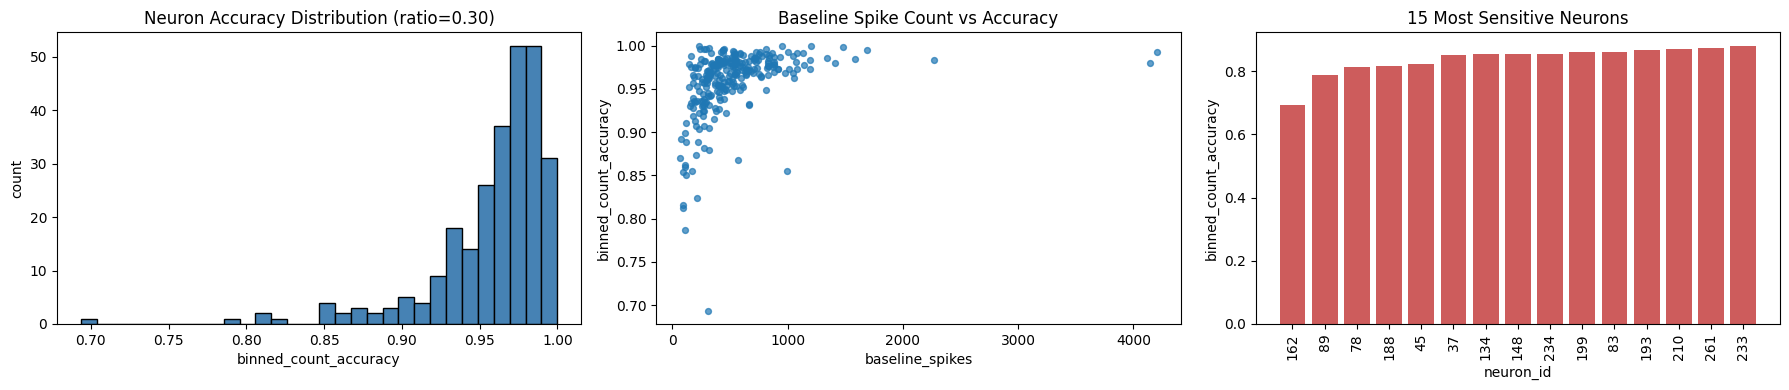

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(neuron_df['binned_count_accuracy'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title(f'Neuron Accuracy Distribution (ratio={analysis_ratio:.2f})')
axes[0].set_xlabel('binned_count_accuracy')
axes[0].set_ylabel('count')

axes[1].scatter(neuron_df['baseline_spikes'], neuron_df['binned_count_accuracy'], s=18, alpha=0.7)
axes[1].set_title('Baseline Spike Count vs Accuracy')
axes[1].set_xlabel('baseline_spikes')
axes[1].set_ylabel('binned_count_accuracy')

top_sensitive = neuron_df.head(15).sort_values('binned_count_accuracy', ascending=True)
axes[2].bar(top_sensitive['neuron_id'].astype(str), top_sensitive['binned_count_accuracy'], color='indianred')
axes[2].set_title('15 Most Sensitive Neurons')
axes[2].set_xlabel('neuron_id')
axes[2].set_ylabel('binned_count_accuracy')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


### Batch Most Sensitive / Robust Neuron Accuracy vs Keep Ratio

This read-only batch plot scans `ROOT` for existing `week5_neuron_sensitivity_ratio_*.npy` files and groups them by DCT window and bin size. For each configuration, it prefers the newer `ratio=1.00` baseline caches (`*_ratio1baseline.npy`); if a configuration has no such caches, it falls back to the existing legacy Week 5 caches so older configurations such as `full_timeline + 15000sampbin` are still plotted.

Each configuration gets its own figure. The selected most sensitive / robust neurons are chosen from `analysis_ratio` when available; otherwise the smallest cached keep ratio for that configuration is used.


,ratio,bin_size_samples,bin_size_seconds,sample_rate,dct_window_label,pipeline_version,baseline_mode,cache_path
0,0.1,15000,0.5,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.1...
1,0.3,15000,0.5,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.3...
2,0.1,30000,1.0,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.1...
3,0.1,30000,1.0,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.1...
4,0.2,30000,1.0,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.2...
5,0.2,30000,1.0,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.2...
6,0.3,30000,1.0,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.3...
7,0.3,30000,1.0,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.3...
8,0.5,30000,1.0,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.5...
9,0.5,30000,1.0,30000.0,full_timeline,int16_main_v3,legacy,G:\academic\week5_neuron_sensitivity_ratio_0.5...


#### DCT=full_timeline, bin=0.5s, baseline=legacy

,neuron_type,neuron_id,ratio,selected_at_ratio,baseline_mode,baseline_spikes,compressed_spikes,matched_spikes_after_binning,binned_count_accuracy,sensitivity
0,most robust,194,0.1,0.3,legacy,1199,446,444,0.370309,0.629691
1,most robust,194,0.3,0.3,legacy,1199,1199,1199,1.000000,0.000000
2,most sensitive,250,0.1,0.3,legacy,73,499,3,0.041096,0.958904
3,most sensitive,250,0.3,0.3,legacy,73,603,2,0.027397,0.972603


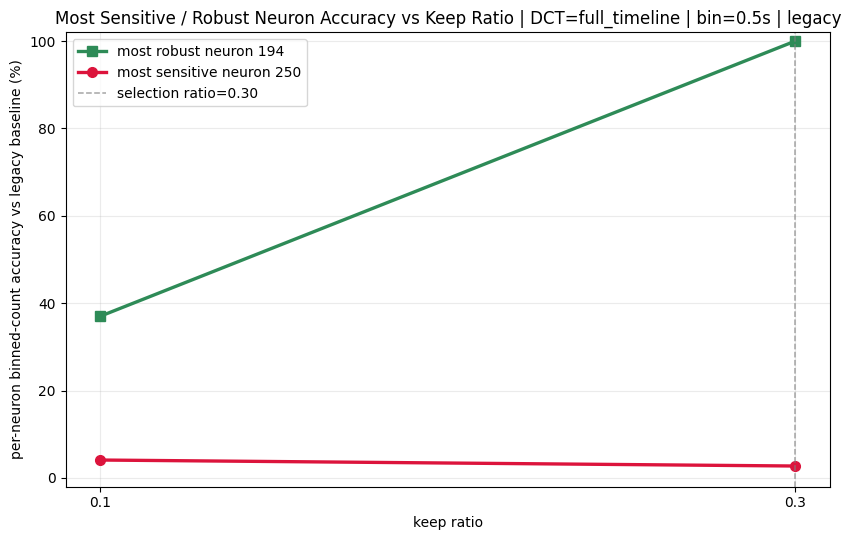

#### DCT=full_timeline, bin=1s, baseline=ratio1baseline

,neuron_type,neuron_id,ratio,selected_at_ratio,baseline_mode,baseline_spikes,compressed_spikes,matched_spikes_after_binning,binned_count_accuracy,sensitivity
0,most robust,176,0.1,0.3,ratio1baseline,231,214,214,0.926407,0.073593
1,most robust,176,0.2,0.3,ratio1baseline,231,231,227,0.982684,0.017316
2,most robust,176,0.3,0.3,ratio1baseline,231,231,231,1.000000,0.000000
3,most robust,176,0.5,0.3,ratio1baseline,231,231,231,1.000000,0.000000
4,most robust,176,0.7,0.3,ratio1baseline,231,231,231,1.000000,0.000000
5,most robust,176,1.0,0.3,ratio1baseline,231,231,231,1.000000,0.000000
6,most sensitive,162,0.1,0.3,ratio1baseline,310,10,9,0.029032,0.970968
7,most sensitive,162,0.2,0.3,ratio1baseline,310,49,49,0.158065,0.841935
8,most sensitive,162,0.3,0.3,ratio1baseline,310,215,215,0.693548,0.306452
9,most sensitive,162,0.5,0.3,ratio1baseline,310,299,299,0.964516,0.035484


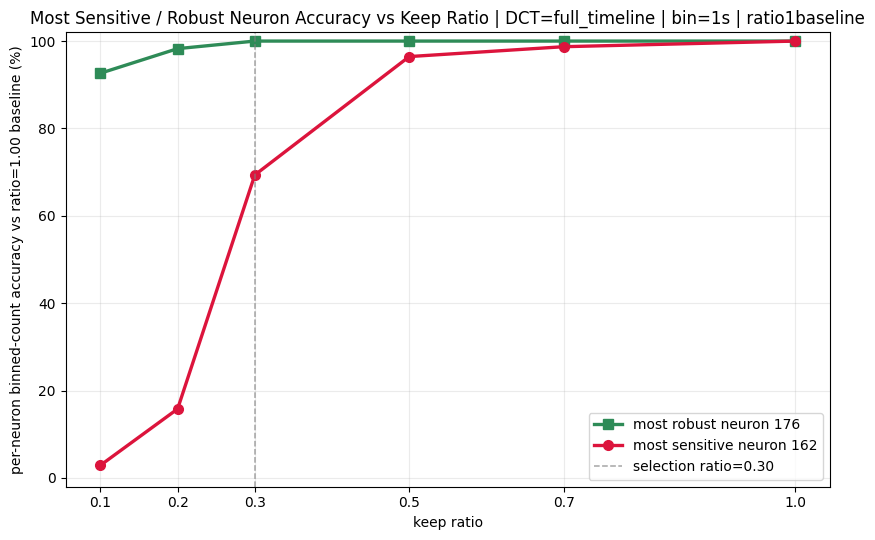

#### DCT=windowed_600_samples, bin=1s, baseline=ratio1baseline

,neuron_type,neuron_id,ratio,selected_at_ratio,baseline_mode,baseline_spikes,compressed_spikes,matched_spikes_after_binning,binned_count_accuracy,sensitivity
0,most robust,135,0.1,0.3,ratio1baseline,242,256,216,0.892562,0.107438
1,most robust,135,0.2,0.3,ratio1baseline,242,240,238,0.983471,0.016529
2,most robust,135,0.3,0.3,ratio1baseline,242,242,242,1.000000,0.000000
3,most robust,135,0.5,0.3,ratio1baseline,242,242,242,1.000000,0.000000
4,most robust,135,0.7,0.3,ratio1baseline,242,242,242,1.000000,0.000000
5,most robust,135,1.0,0.3,ratio1baseline,242,242,242,1.000000,0.000000
6,most sensitive,162,0.1,0.3,ratio1baseline,310,10,9,0.029032,0.970968
7,most sensitive,162,0.2,0.3,ratio1baseline,310,50,50,0.161290,0.838710
8,most sensitive,162,0.3,0.3,ratio1baseline,310,210,210,0.677419,0.322581
9,most sensitive,162,0.5,0.3,ratio1baseline,310,301,299,0.964516,0.035484


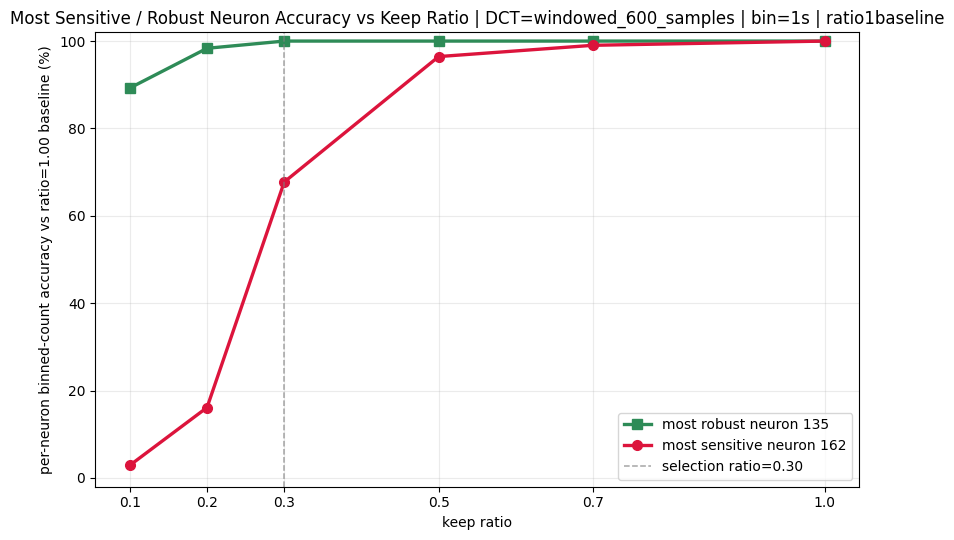

#### Batch curve summary

,dct_window_label,bin_size_samples,bin_size_seconds,sample_rate,baseline_mode,available_ratios,selection_ratio,most_sensitive_neuron_id,most_robust_neuron_id,curve_csv
0,full_timeline,15000,0.5,30000.0,legacy,"[0.1, 0.3]",0.3,250,194,G:\academic\week5_sensitive_robust_neuron_accu...
1,full_timeline,30000,1.0,30000.0,ratio1baseline,"[0.1, 0.2, 0.3, 0.5, 0.7, 1.0]",0.3,162,176,G:\academic\week5_sensitive_robust_neuron_accu...
2,windowed_600_samples,30000,1.0,30000.0,ratio1baseline,"[0.1, 0.2, 0.3, 0.5, 0.7, 1.0]",0.3,162,135,G:\academic\week5_sensitive_robust_neuron_accu...


In [13]:
def discover_week5_neuron_caches_for_batch(root=ROOT):
    rows = []
    for cache_path in sorted(Path(root).glob('week5_neuron_sensitivity_ratio_*.npy')):
        if cache_path.stat().st_size == 0:
            continue
        try:
            payload = np.load(cache_path, allow_pickle=True).item()
        except Exception as exc:
            print(f'skip unreadable cache {cache_path.name}: {exc}')
            continue
        if not isinstance(payload, dict) or 'per_neuron_table' not in payload:
            continue

        ratio = float(payload.get('ratio', np.nan))
        bin_size_samples = int(payload.get('bin_size_samples', -1))
        sample_rate = float(payload.get('sample_rate', np.nan))
        dct_label = payload.get('dct_window_label', 'unknown_dct')
        if not (np.isfinite(ratio) and bin_size_samples > 0 and np.isfinite(sample_rate)):
            continue

        pipeline_version = str(payload.get('pipeline_version', 'unknown_pipeline'))
        is_ratio1baseline = cache_path.name.endswith('_ratio1baseline.npy') or payload.get('reference_baseline_ratio') == WEEK5_REFERENCE_BASELINE_RATIO
        rows.append({
            'ratio': ratio,
            'bin_size_samples': bin_size_samples,
            'bin_size_seconds': bin_size_samples / sample_rate,
            'sample_rate': sample_rate,
            'dct_window_label': dct_label,
            'pipeline_version': pipeline_version,
            'baseline_mode': 'ratio1baseline' if is_ratio1baseline else 'legacy',
            'cache_path': cache_path,
            'payload': payload,
        })
    return pd.DataFrame(rows)


def _safe_config_tag(text):
    return ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(text))


def _select_batch_cache_rows(config_cache_df):
    # Prefer the current ratio=1.00 baseline cache family when present for a config.
    preferred = config_cache_df[config_cache_df['baseline_mode'] == 'ratio1baseline'].copy()
    selected = preferred if not preferred.empty else config_cache_df.copy()
    selected = selected.copy()
    selected['dedupe_score'] = 0
    selected.loc[selected['baseline_mode'] == 'ratio1baseline', 'dedupe_score'] += 100
    selected.loc[selected['pipeline_version'].eq(globals().get('WEEK5_PIPELINE_VERSION', '')), 'dedupe_score'] += 50
    selected.loc[selected['cache_path'].astype(str).str.contains('sampbin', regex=False), 'dedupe_score'] += 10
    selected = selected.sort_values(['ratio', 'dedupe_score', 'cache_path'], ascending=[True, False, True])
    return selected.drop_duplicates(subset=['ratio'], keep='first').drop(columns=['dedupe_score'])


week5_cache_index_df = discover_week5_neuron_caches_for_batch(root=ROOT)
if week5_cache_index_df.empty:
    raise FileNotFoundError('No Week 5 neuron caches found under ROOT.')

display(week5_cache_index_df.drop(columns=['payload']).sort_values([
    'dct_window_label',
    'bin_size_samples',
    'baseline_mode',
    'ratio',
]).reset_index(drop=True))

all_curve_summaries = []
all_selected_curve_rows = []
preferred_selection_ratio = float(globals().get('analysis_ratio', 0.30))
config_cols = ['dct_window_label', 'bin_size_samples', 'sample_rate']

for config_key, raw_config_cache_df in week5_cache_index_df.groupby(config_cols, sort=True):
    dct_label, bin_size_samples, sample_rate = config_key
    config_cache_df = _select_batch_cache_rows(raw_config_cache_df).sort_values('ratio').reset_index(drop=True)
    available_ratios = config_cache_df['ratio'].astype(float).tolist()
    if not available_ratios:
        continue

    baseline_modes = sorted(config_cache_df['baseline_mode'].unique().tolist())
    baseline_mode = baseline_modes[0] if len(baseline_modes) == 1 else '+'.join(baseline_modes)
    if any(np.isclose(available_ratios, preferred_selection_ratio)):
        selection_ratio = available_ratios[int(np.where(np.isclose(available_ratios, preferred_selection_ratio))[0][0])]
    else:
        selection_ratio = min(available_ratios)

    per_ratio_tables = {}
    for _, cache_row in config_cache_df.iterrows():
        ratio = float(cache_row['ratio'])
        table_df = pd.DataFrame(cache_row['payload']['per_neuron_table'])
        if table_df.empty:
            continue
        table_df = table_df.copy()
        table_df['neuron_id'] = table_df['neuron_id'].astype(int)
        table_df['ratio'] = ratio
        table_df['pipeline_version'] = cache_row['pipeline_version']
        table_df['baseline_mode'] = cache_row['baseline_mode']
        table_df['cache_path'] = str(cache_row['cache_path'])
        per_ratio_tables[ratio] = table_df

    if selection_ratio not in per_ratio_tables:
        print(f'skip config DCT={dct_label}, bin={bin_size_samples}: missing selection ratio table')
        continue

    selection_df = per_ratio_tables[selection_ratio]
    selection_df = selection_df[selection_df['baseline_spikes'] > 0].copy()
    if selection_df.empty:
        print(f'skip config DCT={dct_label}, bin={bin_size_samples}: no baseline-spiking neurons')
        continue

    most_sensitive_row = selection_df.sort_values(
        ['binned_count_accuracy', 'baseline_spikes'],
        ascending=[True, False],
    ).iloc[0]
    most_robust_row = selection_df.sort_values(
        ['binned_count_accuracy', 'baseline_spikes'],
        ascending=[False, False],
    ).iloc[0]
    selected_specs = [
        ('most sensitive', int(most_sensitive_row['neuron_id'])),
        ('most robust', int(most_robust_row['neuron_id'])),
    ]

    curve_rows = []
    for ratio, table_df in per_ratio_tables.items():
        for neuron_type, neuron_id in selected_specs:
            matched = table_df[table_df['neuron_id'] == neuron_id].copy()
            if matched.empty:
                continue
            matched['neuron_type'] = neuron_type
            matched['selected_at_ratio'] = selection_ratio
            matched['dct_window_label'] = dct_label
            matched['bin_size_samples'] = int(bin_size_samples)
            matched['bin_size_seconds'] = int(bin_size_samples) / float(sample_rate)
            matched['sample_rate'] = float(sample_rate)
            curve_rows.append(matched)

    if not curve_rows:
        print(f'skip config DCT={dct_label}, bin={bin_size_samples}: selected neurons absent from ratio tables')
        continue

    selected_curve_df = pd.concat(curve_rows, ignore_index=True)
    selected_curve_df = selected_curve_df.sort_values(['neuron_type', 'ratio']).reset_index(drop=True)
    all_selected_curve_rows.append(selected_curve_df)

    config_tag = f'{_safe_config_tag(dct_label)}_{int(bin_size_samples)}sampbin_{baseline_mode}'
    curve_csv = ROOT / f'week5_sensitive_robust_neuron_accuracy_by_ratio_{config_tag}.csv'
    selected_curve_df.to_csv(curve_csv, index=False)

    display(Markdown(f'#### DCT={dct_label}, bin={int(bin_size_samples) / float(sample_rate):g}s, baseline={baseline_mode}'))
    display(selected_curve_df[[
        'neuron_type',
        'neuron_id',
        'ratio',
        'selected_at_ratio',
        'baseline_mode',
        'baseline_spikes',
        'compressed_spikes',
        'matched_spikes_after_binning',
        'binned_count_accuracy',
        'sensitivity',
    ]])

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    plot_styles = {
        'most sensitive': {'color': 'crimson', 'marker': 'o'},
        'most robust': {'color': 'seagreen', 'marker': 's'},
    }
    for neuron_type, group in selected_curve_df.groupby('neuron_type', sort=False):
        group = group.sort_values('ratio')
        neuron_id = int(group['neuron_id'].iloc[0])
        ax.plot(
            group['ratio'],
            group['binned_count_accuracy'] * 100.0,
            linewidth=2.4,
            markersize=7,
            label=f'{neuron_type} neuron {neuron_id}',
            **plot_styles[neuron_type],
        )

    ax.axvline(
        float(selection_ratio),
        color='gray',
        linestyle='--',
        linewidth=1.1,
        alpha=0.7,
        label=f'selection ratio={selection_ratio:.2f}',
    )
    ylabel_suffix = 'ratio=1.00 baseline' if baseline_mode == 'ratio1baseline' else 'legacy baseline'
    ax.set_title(
        f'Most Sensitive / Robust Neuron Accuracy vs Keep Ratio | '
        f'DCT={dct_label} | bin={int(bin_size_samples) / float(sample_rate):g}s | {baseline_mode}'
    )
    ax.set_xlabel('keep ratio')
    ax.set_ylabel(f'per-neuron binned-count accuracy vs {ylabel_suffix} (%)')
    ax.set_ylim(-2, 102)
    ax.set_xticks(sorted(selected_curve_df['ratio'].unique()))
    ax.grid(alpha=0.25)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

    all_curve_summaries.append({
        'dct_window_label': dct_label,
        'bin_size_samples': int(bin_size_samples),
        'bin_size_seconds': int(bin_size_samples) / float(sample_rate),
        'sample_rate': float(sample_rate),
        'baseline_mode': baseline_mode,
        'available_ratios': available_ratios,
        'selection_ratio': float(selection_ratio),
        'most_sensitive_neuron_id': int(most_sensitive_row['neuron_id']),
        'most_robust_neuron_id': int(most_robust_row['neuron_id']),
        'curve_csv': str(curve_csv),
    })

week5_sensitive_robust_curve_summary_df = pd.DataFrame(all_curve_summaries)
if not week5_sensitive_robust_curve_summary_df.empty:
    display(Markdown('#### Batch curve summary'))
    display(week5_sensitive_robust_curve_summary_df)

if all_selected_curve_rows:
    week5_sensitive_robust_all_curves_df = pd.concat(all_selected_curve_rows, ignore_index=True)
else:
    week5_sensitive_robust_all_curves_df = pd.DataFrame()


### Additional Visual Diagnostics

The following cells provide three more intuitive views:

1. a 2D projection of baseline templates, colored by peak power
2. a side-by-side comparison of one sensitive neuron and one robust neuron
3. the keep-ratio requirement under different allowed sorting-error thresholds


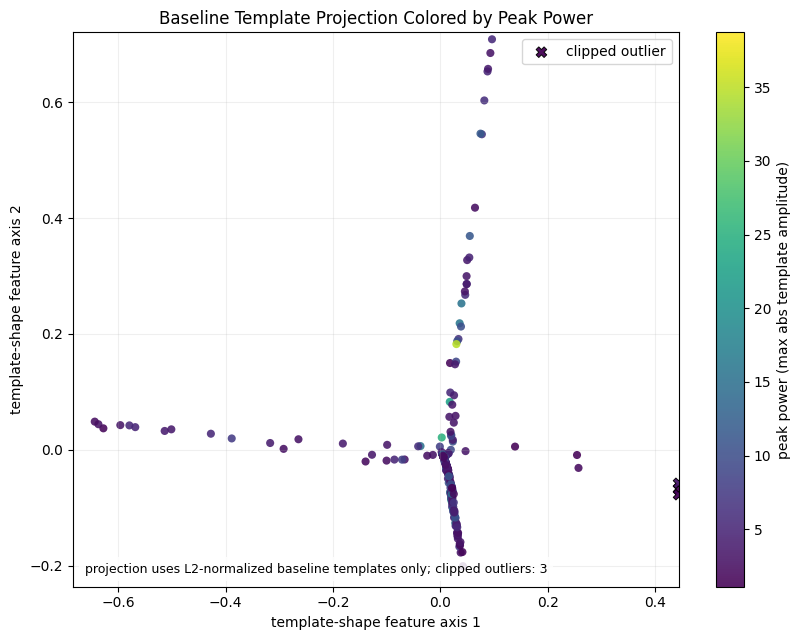

In [14]:
template_embedding_df, x_lim, y_lim = render_template_projection_for_current_config(templates_base)


Sensitive neuron id: 162
Robust neuron id: 176


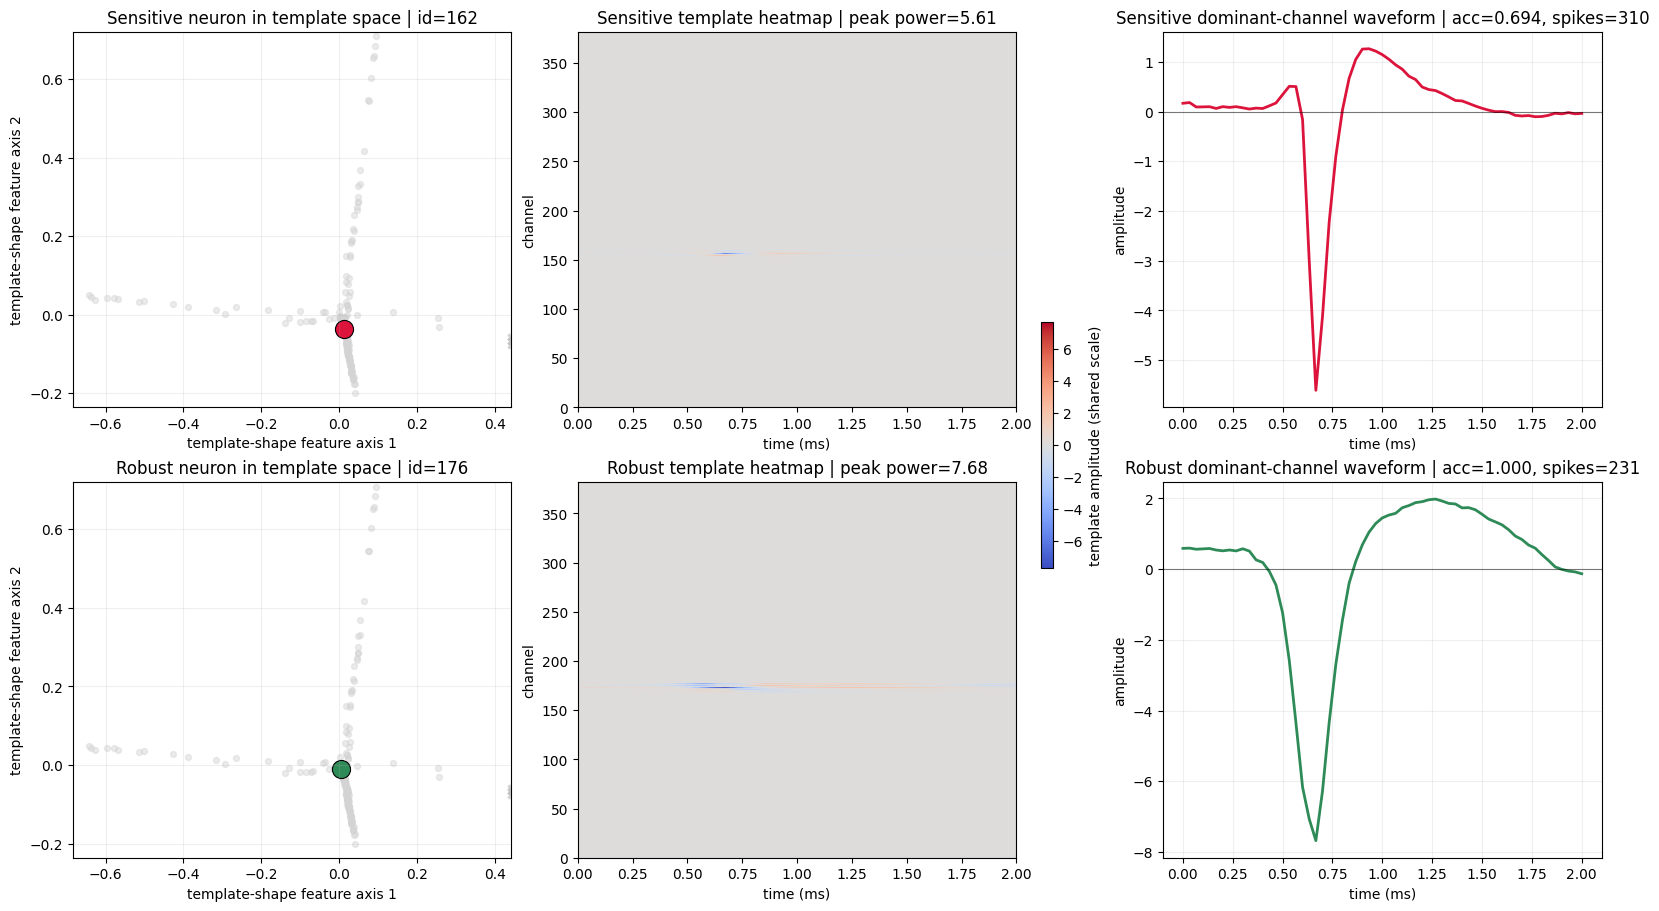

In [15]:
valid_neuron_rows = neuron_df[neuron_df['neuron_id'].between(0, templates_base.shape[0] - 1)].copy()
if valid_neuron_rows.empty:
    raise RuntimeError('No neuron ids map cleanly onto templates_base indices for the sensitive/robust plot.')

sensitive_row = valid_neuron_rows.sort_values(['binned_count_accuracy', 'baseline_spikes'], ascending=[True, False]).iloc[0]
robust_row = valid_neuron_rows.sort_values(['binned_count_accuracy', 'baseline_spikes'], ascending=[False, False]).iloc[0]
comparison_rows = [('Sensitive', sensitive_row, 'crimson'), ('Robust', robust_row, 'seagreen')]
time_ms = (np.arange(nt) / float(ops_base['fs'])) * 1000.0

comparison_templates = [templates_base[int(row['neuron_id'])].astype(np.float32, copy=False) for _, row, _ in comparison_rows]
shared_abs_max = max(float(np.max(np.abs(tpl))) for tpl in comparison_templates)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
heatmap_images = []
for row_idx, (label, row, color) in enumerate(comparison_rows):
    neuron_id = int(row['neuron_id'])
    template = templates_base[neuron_id].astype(np.float32, copy=False)
    channel_ptp = np.ptp(template, axis=0)
    dominant_channel = int(np.argmax(channel_ptp))
    dominant_waveform = template[:, dominant_channel]
    peak_power = float(np.max(np.abs(template)))

    ax0 = axes[row_idx, 0]
    inlier_df = template_embedding_df.loc[~template_embedding_df['is_outlier']]
    outlier_df = template_embedding_df.loc[template_embedding_df['is_outlier']]
    ax0.scatter(inlier_df['pc1_plot'], inlier_df['pc2_plot'], c='lightgray', s=18, alpha=0.45)
    if not outlier_df.empty:
        ax0.scatter(outlier_df['pc1_plot'], outlier_df['pc2_plot'], c='silver', s=30, alpha=0.65, marker='X', linewidths=0.4)
    ax0.scatter(
        template_embedding_df.loc[neuron_id, 'pc1_plot'],
        template_embedding_df.loc[neuron_id, 'pc2_plot'],
        c=color,
        s=170,
        edgecolors='black',
        linewidths=0.8,
    )
    ax0.set_title(f'{label} neuron in template space | id={neuron_id}')
    ax0.set_xlabel('template-shape feature axis 1')
    ax0.set_ylabel('template-shape feature axis 2')
    ax0.set_xlim(x_lim)
    ax0.set_ylim(y_lim)
    ax0.grid(alpha=0.2)

    ax1 = axes[row_idx, 1]
    im = ax1.imshow(
        template.T,
        aspect='auto',
        origin='lower',
        cmap='coolwarm',
        vmin=-shared_abs_max,
        vmax=shared_abs_max,
        extent=[time_ms[0], time_ms[-1], 0, template.shape[1] - 1],
    )
    heatmap_images.append(im)
    ax1.set_title(f'{label} template heatmap | peak power={peak_power:.3g}')
    ax1.set_xlabel('time (ms)')
    ax1.set_ylabel('channel')

    ax2 = axes[row_idx, 2]
    ax2.plot(time_ms, dominant_waveform, color=color, linewidth=2)
    ax2.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
    ax2.set_title(
        f"{label} dominant-channel waveform | acc={float(row['binned_count_accuracy']):.3f}, spikes={int(row['baseline_spikes'])}"
    )
    ax2.set_xlabel('time (ms)')
    ax2.set_ylabel('amplitude')
    ax2.grid(alpha=0.2)

fig.colorbar(heatmap_images[0], ax=axes[:, 1], fraction=0.028, pad=0.02, label='template amplitude (shared scale)')
print('Sensitive neuron id:', int(sensitive_row['neuron_id']))
print('Robust neuron id:', int(robust_row['neuron_id']))
plt.show()



loaded cached neuron table for ratio=0.10: week5_neuron_sensitivity_ratio_0.10_full_30000sampbin_ratio1baseline.npy
loaded cached neuron table for ratio=0.20: week5_neuron_sensitivity_ratio_0.20_full_30000sampbin_ratio1baseline.npy
loaded cached neuron table for ratio=0.30: week5_neuron_sensitivity_ratio_0.30_full_30000sampbin_ratio1baseline.npy
loaded cached neuron table for ratio=0.50: week5_neuron_sensitivity_ratio_0.50_full_30000sampbin_ratio1baseline.npy
loaded cached neuron table for ratio=0.70: week5_neuron_sensitivity_ratio_0.70_full_30000sampbin_ratio1baseline.npy
loaded cached neuron table for ratio=1.00: week5_neuron_sensitivity_ratio_1.00_full_30000sampbin_ratio1baseline.npy


,allowed_sorting_error_pct,min_keep_ratio,is_requested_threshold,reachable
0,40.29,0.1,False,True
1,10.00,0.3,True,True
2,5.00,0.3,True,True
3,2.00,0.5,True,True
4,1.00,0.5,True,True
5,0.25,1.0,False,True


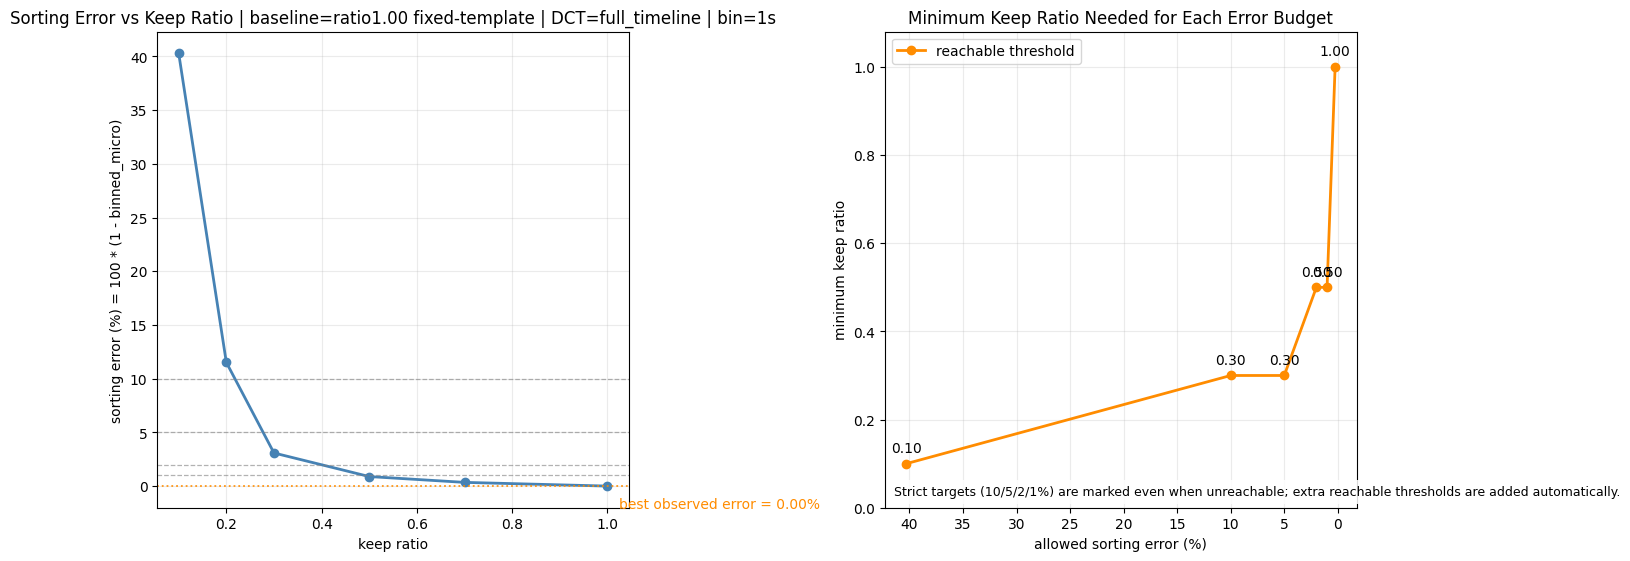

In [16]:
if week4_ratio_df is None:
    ratio_rows = []
    for ratio in [0.10, 0.20, 0.30, 0.50, 0.70, 1.00]:
        ratio_neuron_df = load_or_build_week5_neuron_table(
            ratio,
            st_ref,
            clu_ref,
            U=U,
            ctc=ctc,
            ops_tm=ops_tm,
            n_use=n_use,
            nt=nt,
            device=device,
            bin_size_samples=week5_bin_size_samples,
            sample_rate=float(ops_base['fs']),
            window_samples=DCT_WINDOW_SAMPLES,
        )
        summary = build_ratio_summary_from_neuron_df(ratio, ratio_neuron_df)
        if summary is not None:
            ratio_rows.append(summary)
    ratio_plot_df = pd.DataFrame(ratio_rows)
else:
    ratio_plot_df = week4_ratio_df.copy()
    if 'binned_count_accuracy_micro_vs_ratio100' in ratio_plot_df.columns:
        ratio_plot_df = ratio_plot_df.rename(columns={
            'binned_count_accuracy_micro_vs_ratio100': 'binned_count_accuracy_micro',
            'binned_count_accuracy_macro_vs_ratio100': 'binned_count_accuracy_macro',
            'matched_spikes_after_binning_vs_ratio100': 'matched_spikes_after_binning',
            'baseline_spikes_for_binning_vs_ratio100': 'baseline_spikes_for_binning',
        })

if ratio_plot_df.empty:
    print('No ratio=1.00-baseline ratio-evaluation table could be built for the current DCT window and bin configuration.')
else:
    ratio_plot_df['ratio'] = ratio_plot_df['ratio'].astype(float)
    ratio_plot_df['sorting_error_pct'] = 100.0 * (1.0 - ratio_plot_df['binned_count_accuracy_micro'].astype(float))
    ratio_plot_df = ratio_plot_df.sort_values('ratio').reset_index(drop=True)

    requested_thresholds_pct = [10.0, 5.0, 2.0, 1.0]
    min_error_pct = float(ratio_plot_df['sorting_error_pct'].min())
    max_error_pct = float(ratio_plot_df['sorting_error_pct'].max())
    adaptive_thresholds_pct = sorted({
        round(min_error_pct + 0.25, 2),
        round(min_error_pct + 1.0, 2),
        round(min_error_pct + 5.0, 2),
        round(max_error_pct, 2),
    })

    threshold_rows = []
    for thr in requested_thresholds_pct + adaptive_thresholds_pct:
        feasible = ratio_plot_df.loc[ratio_plot_df['sorting_error_pct'] <= thr, 'ratio']
        threshold_rows.append({
            'allowed_sorting_error_pct': float(thr),
            'min_keep_ratio': float(feasible.min()) if not feasible.empty else np.nan,
            'is_requested_threshold': thr in requested_thresholds_pct,
            'reachable': not feasible.empty,
        })
    threshold_df = pd.DataFrame(threshold_rows).drop_duplicates(subset=['allowed_sorting_error_pct']).sort_values('allowed_sorting_error_pct', ascending=False).reset_index(drop=True)
    display(threshold_df)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

    axes[0].plot(ratio_plot_df['ratio'], ratio_plot_df['sorting_error_pct'], marker='o', linewidth=2, color='steelblue')
    for thr in requested_thresholds_pct:
        axes[0].axhline(thr, color='gray', linestyle='--', linewidth=0.9, alpha=0.6)
    axes[0].axhline(min_error_pct, color='darkorange', linestyle=':', linewidth=1.3, alpha=0.9)
    axes[0].annotate(f'best observed error = {min_error_pct:.2f}%', (ratio_plot_df.loc[ratio_plot_df['sorting_error_pct'].idxmin(), 'ratio'], min_error_pct), textcoords='offset points', xytext=(8, -16), ha='left', color='darkorange')
    axes[0].set_title(f'Sorting Error vs Keep Ratio | baseline=ratio1.00 fixed-template | DCT={dct_window_label()} | bin={WEEK5_BIN_SIZE_SECONDS:g}s')
    axes[0].set_xlabel('keep ratio')
    axes[0].set_ylabel('sorting error (%) = 100 * (1 - binned_micro)')
    axes[0].grid(alpha=0.25)

    reachable_df = threshold_df[threshold_df['reachable']].copy()
    unreachable_df = threshold_df[~threshold_df['reachable']].copy()

    if not reachable_df.empty:
        axes[1].plot(reachable_df['allowed_sorting_error_pct'], reachable_df['min_keep_ratio'], marker='o', linewidth=2, color='darkorange', label='reachable threshold')
        for _, row in reachable_df.iterrows():
            axes[1].annotate(f"{row['min_keep_ratio']:.2f}", (row['allowed_sorting_error_pct'], row['min_keep_ratio']), textcoords='offset points', xytext=(0, 8), ha='center')
    if not unreachable_df.empty:
        axes[1].scatter(unreachable_df['allowed_sorting_error_pct'], [1.02] * len(unreachable_df), marker='x', s=70, color='crimson', label='unreachable with current ratios')
        for _, row in unreachable_df.iterrows():
            axes[1].annotate('unreachable', (row['allowed_sorting_error_pct'], 1.02), textcoords='offset points', xytext=(0, 8), ha='center', color='crimson', fontsize=9)

    axes[1].set_title('Minimum Keep Ratio Needed for Each Error Budget')
    axes[1].set_xlabel('allowed sorting error (%)')
    axes[1].set_ylabel('minimum keep ratio')
    axes[1].invert_xaxis()
    axes[1].set_ylim(0.0, 1.08)
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='best')
    axes[1].text(
        0.02,
        0.02,
        'Strict targets (10/5/2/1%) are marked even when unreachable; extra reachable thresholds are added automatically.',
        transform=axes[1].transAxes,
        fontsize=9,
        ha='left',
        va='bottom',
        bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'none'},
    )

    plt.show()


### Batch Visualization From Cached Week 4 / Week 5 Results

The next cell is read-only by default: it scans existing cached configurations and renders figures without recomputing data.

If a configuration is missing Week 5 neuron-level cache, the sensitive/robust neuron figure will be skipped for that configuration, while the other cache-backed figures will still be shown.

Only run the optional backfill cell if you explicitly want to generate missing Week 5 neuron-level caches from existing Week 4 outputs.


#### Cached config: DCT=full_timeline, bin=0.5s

Week 4 ratio table: G:\academic\week4_fixed_template_ratio_compare_15000samp.csv


,ratio,n_baseline_events,n_detected_events,detection_rate_on_baseline_events,classification_accuracy_on_detected_events,binned_count_accuracy_micro,binned_count_accuracy_macro,matched_spikes_after_binning,baseline_spikes_for_binning,bin_size_seconds,int16_bin,source_float32_bin,int16_meta
0,0.1,137378,14946,0.108795,0.227151,0.553708,0.537974,76069,137381,0.5,G:\academic\whitened_recon_ratio_0.10_int16.bin,G:\academic\whitened_recon_ratio_0.10.bin,G:\academic\whitened_recon_ratio_0.10_int16_me...
1,0.2,137378,16362,0.119102,0.245080,0.763876,0.721906,104942,137381,0.5,G:\academic\whitened_recon_ratio_0.20_int16.bin,G:\academic\whitened_recon_ratio_0.20.bin,G:\academic\whitened_recon_ratio_0.20_int16_me...
2,0.3,137378,16448,0.119728,0.251946,0.814545,0.744627,111903,137381,0.5,G:\academic\whitened_recon_ratio_0.30_int16.bin,G:\academic\whitened_recon_ratio_0.30.bin,G:\academic\whitened_recon_ratio_0.30_int16_me...
3,0.5,137378,16935,0.123273,0.251078,0.815579,0.744355,112045,137381,0.5,G:\academic\whitened_recon_ratio_0.50_int16.bin,G:\academic\whitened_recon_ratio_0.50.bin,G:\academic\whitened_recon_ratio_0.50_int16_me...
4,0.7,137378,17246,0.125537,0.250841,0.815542,0.744446,112040,137381,0.5,G:\academic\whitened_recon_ratio_0.70_int16.bin,G:\academic\whitened_recon_ratio_0.70.bin,G:\academic\whitened_recon_ratio_0.70_int16_me...
5,1.0,137378,17049,0.124103,0.251569,0.815549,0.744630,112041,137381,0.5,G:\academic\whitened_recon_ratio_1.00_int16.bin,G:\academic\whitened_recon_ratio_1.00.bin,G:\academic\whitened_recon_ratio_1.00_int16_me...


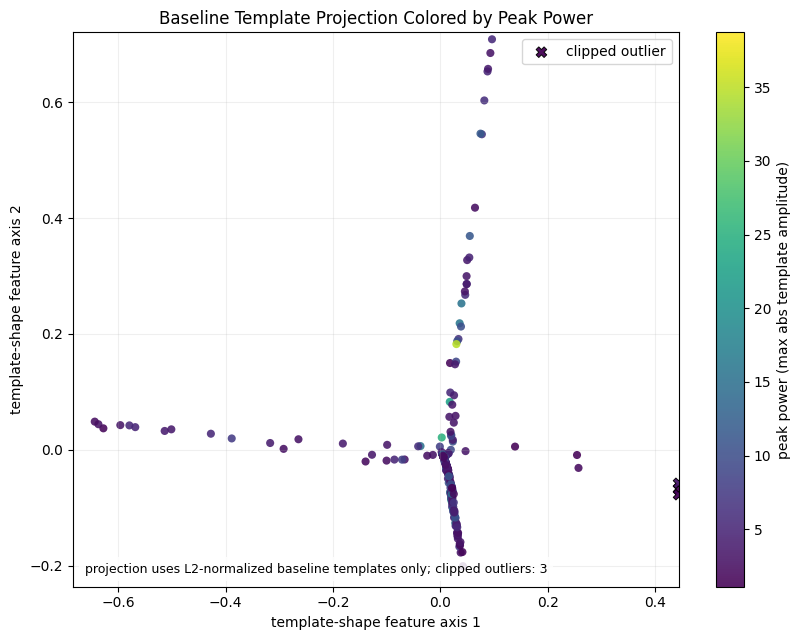

No matching Week 5 neuron-level cache found; skipping sensitive/robust neuron figure.


,allowed_sorting_error_pct,min_keep_ratio,is_requested_threshold,reachable
0,44.63,0.1,False,True
1,23.44,0.3,False,True
2,19.44,0.3,False,True
3,18.69,0.3,False,True
4,10.00,NaN,True,False
5,5.00,NaN,True,False
6,2.00,NaN,True,False
7,1.00,NaN,True,False


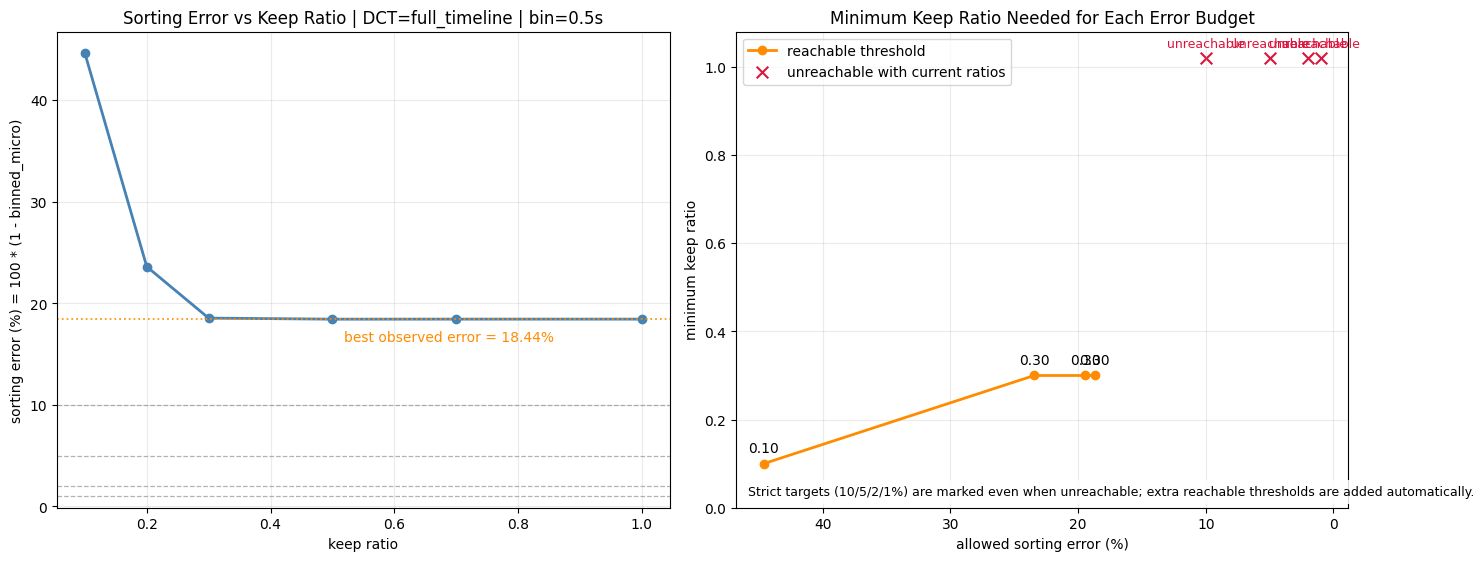

#### Cached config: DCT=full_timeline, bin=1s

Week 4 ratio table: G:\academic\week4_fixed_template_ratio_compare.csv


,ratio,n_baseline_events,n_detected_events,detection_rate_on_baseline_events,classification_accuracy_on_detected_events,binned_count_accuracy_micro,binned_count_accuracy_macro,matched_spikes_after_binning,baseline_spikes_for_binning,bin_size_seconds,int16_bin,source_float32_bin,int16_meta
0,0.1,137378,14946,0.108795,0.227151,0.564569,0.544023,77561,137381,1.0,G:\academic\whitened_recon_ratio_0.10_int16.bin,G:\academic\whitened_recon_ratio_0.10.bin,G:\academic\whitened_recon_ratio_0.10_int16_me...
1,0.2,137378,16362,0.119102,0.245080,0.774336,0.716907,106379,137381,1.0,G:\academic\whitened_recon_ratio_0.20_int16.bin,G:\academic\whitened_recon_ratio_0.20.bin,G:\academic\whitened_recon_ratio_0.20_int16_me...
2,0.3,137378,16448,0.119728,0.251946,0.823163,0.734769,113087,137381,1.0,G:\academic\whitened_recon_ratio_0.30_int16.bin,G:\academic\whitened_recon_ratio_0.30.bin,G:\academic\whitened_recon_ratio_0.30_int16_me...
3,0.5,137378,16935,0.123273,0.251078,0.823746,0.734504,113167,137381,1.0,G:\academic\whitened_recon_ratio_0.50_int16.bin,G:\academic\whitened_recon_ratio_0.50.bin,G:\academic\whitened_recon_ratio_0.50_int16_me...
4,0.7,137378,17246,0.125537,0.250841,0.823877,0.734444,113185,137381,1.0,G:\academic\whitened_recon_ratio_0.70_int16.bin,G:\academic\whitened_recon_ratio_0.70.bin,G:\academic\whitened_recon_ratio_0.70_int16_me...
5,1.0,137378,17049,0.124103,0.251569,0.823724,0.734276,113164,137381,1.0,G:\academic\whitened_recon_ratio_1.00_int16.bin,G:\academic\whitened_recon_ratio_1.00.bin,G:\academic\whitened_recon_ratio_1.00_int16_me...


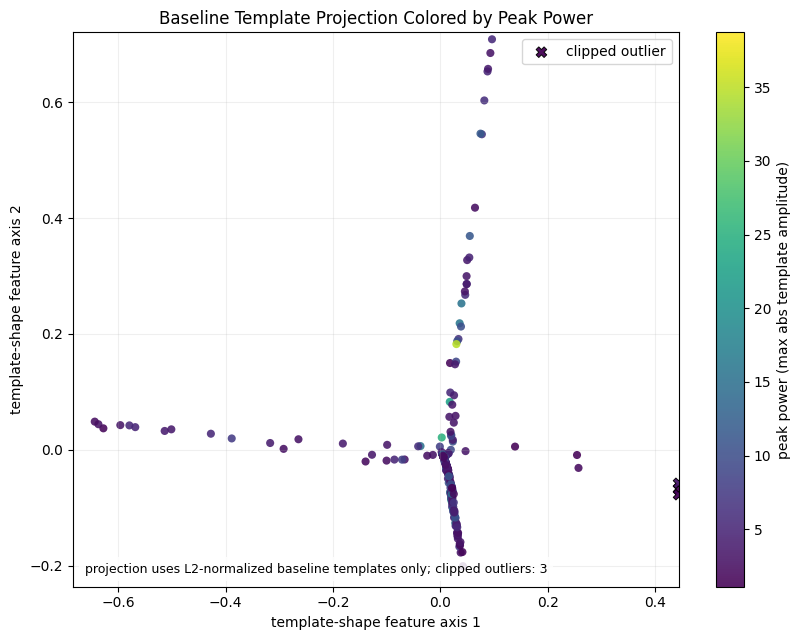

loaded cached Week 5 neuron table for ratio=0.30: week5_neuron_sensitivity_ratio_0.30_full_30000sampbin_ratio1baseline.npy
Sensitive neuron id: 162
Robust neuron id: 176


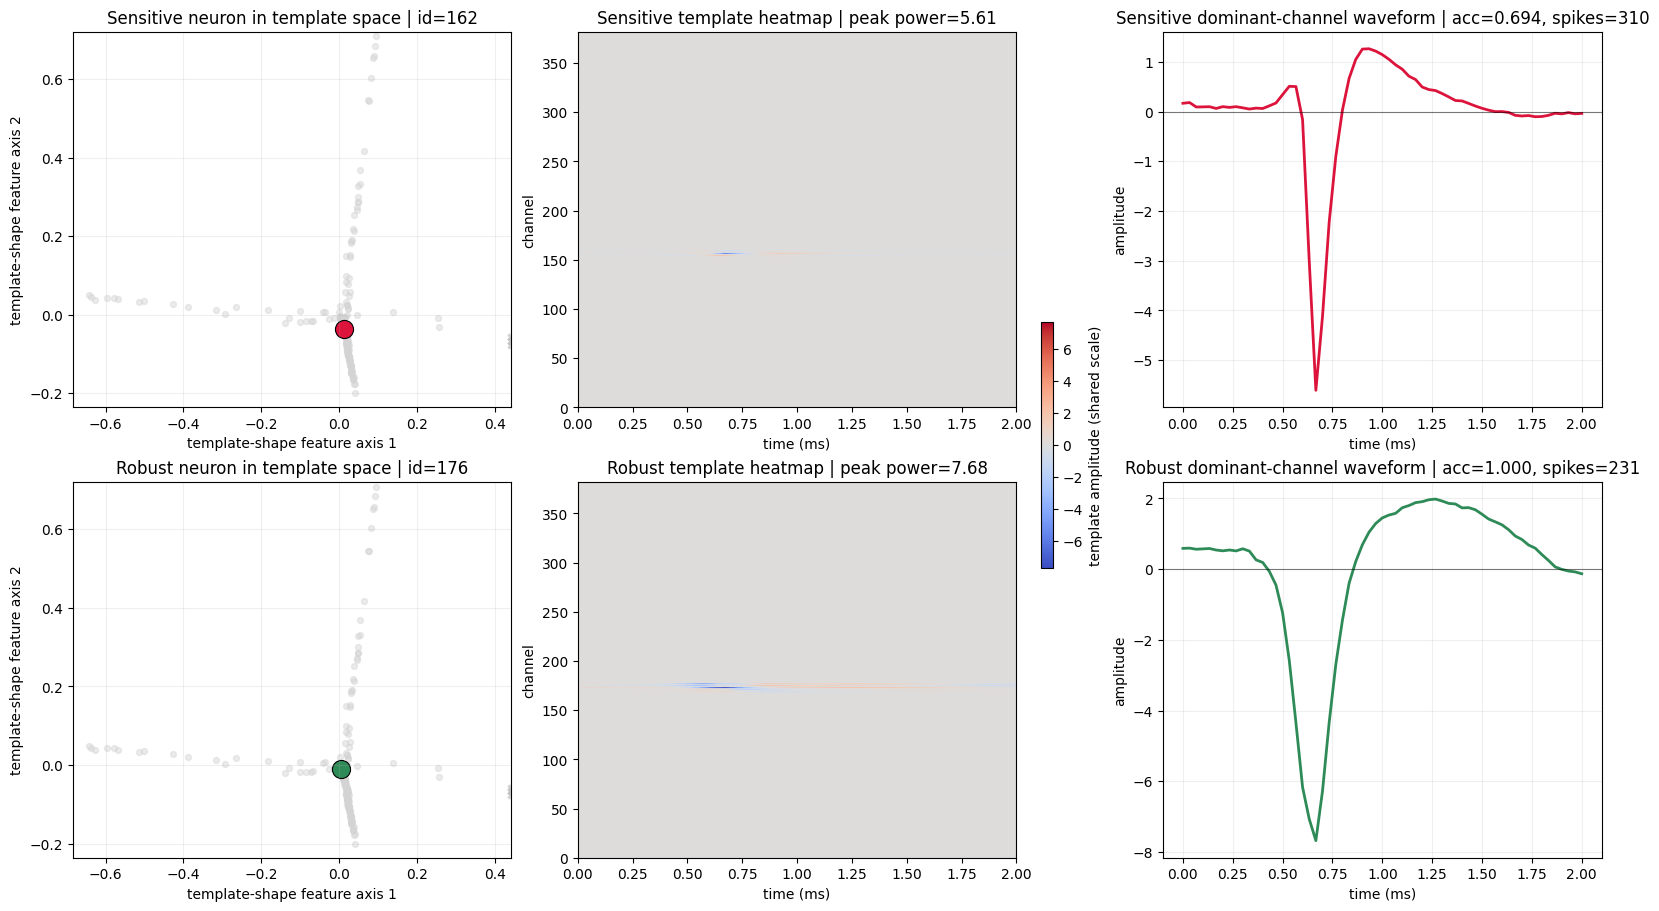

,allowed_sorting_error_pct,min_keep_ratio,is_requested_threshold,reachable
0,43.54,0.2,False,True
1,22.61,0.2,False,True
2,18.61,0.3,False,True
3,17.86,0.3,False,True
4,10.00,NaN,True,False
5,5.00,NaN,True,False
6,2.00,NaN,True,False
7,1.00,NaN,True,False


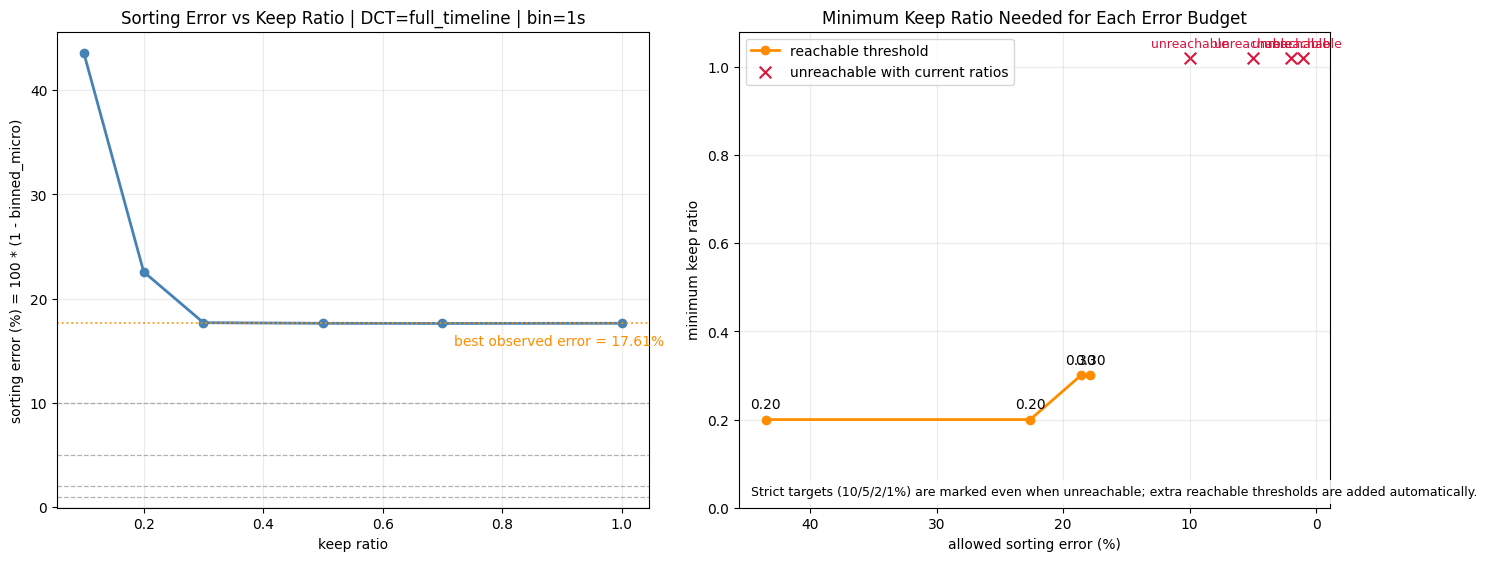

#### Cached config: DCT=windowed_600_samples, bin=0.02s

Week 4 ratio=1.00-baseline table: G:\academic\week4_fixed_template_ratio_compare_dctwin_600samp_600samp_ratio1baseline.csv


,ratio,baseline_reference,binned_count_accuracy_micro_vs_ratio100,binned_count_accuracy_macro_vs_ratio100,matched_spikes_after_binning_vs_ratio100,baseline_spikes_for_binning_vs_ratio100,bin_size_seconds,compressed_bin,int16_meta,sample_rate,source_compare_df
0,0.1,ratio_1.00_fixed_template_rerun,0.540524,0.556159,76603,141720,0.02,G:\academic\whitened_recon_ratio_0.10_dctwin_6...,G:\academic\whitened_recon_ratio_0.10_dctwin_6...,30000.0,custom_compare_df
1,0.2,ratio_1.00_fixed_template_rerun,0.871190,0.888064,123465,141720,0.02,G:\academic\whitened_recon_ratio_0.20_dctwin_6...,G:\academic\whitened_recon_ratio_0.20_dctwin_6...,30000.0,custom_compare_df
2,0.3,ratio_1.00_fixed_template_rerun,0.970018,0.970042,137471,141720,0.02,G:\academic\whitened_recon_ratio_0.30_dctwin_6...,G:\academic\whitened_recon_ratio_0.30_dctwin_6...,30000.0,custom_compare_df
3,0.5,ratio_1.00_fixed_template_rerun,0.993417,0.993463,140787,141720,0.02,G:\academic\whitened_recon_ratio_0.50_dctwin_6...,G:\academic\whitened_recon_ratio_0.50_dctwin_6...,30000.0,custom_compare_df
4,0.7,ratio_1.00_fixed_template_rerun,0.997241,0.997355,141329,141720,0.02,G:\academic\whitened_recon_ratio_0.70_dctwin_6...,G:\academic\whitened_recon_ratio_0.70_dctwin_6...,30000.0,custom_compare_df
5,1.0,ratio_1.00_fixed_template_rerun,1.000000,1.000000,141720,141720,0.02,G:\academic\whitened_recon_ratio_1.00_dctwin_6...,G:\academic\whitened_recon_ratio_1.00_dctwin_6...,30000.0,custom_compare_df


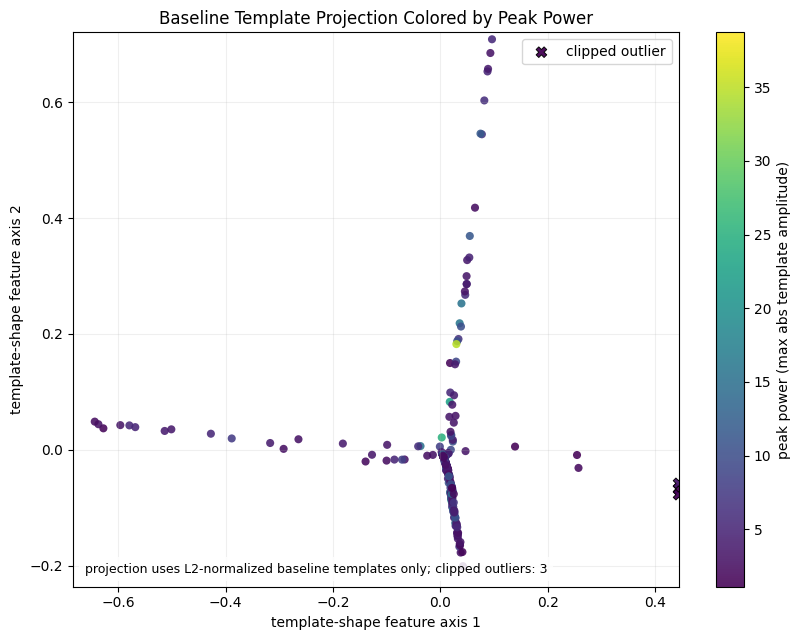

No matching Week 5 neuron-level cache found; skipping sensitive/robust neuron figure.


,allowed_sorting_error_pct,min_keep_ratio,is_requested_threshold,reachable
0,45.95,0.1,False,True
1,10.00,0.3,True,True
2,5.00,0.3,True,True
3,2.00,0.5,True,True
4,1.00,0.5,True,True
5,0.25,1.0,False,True


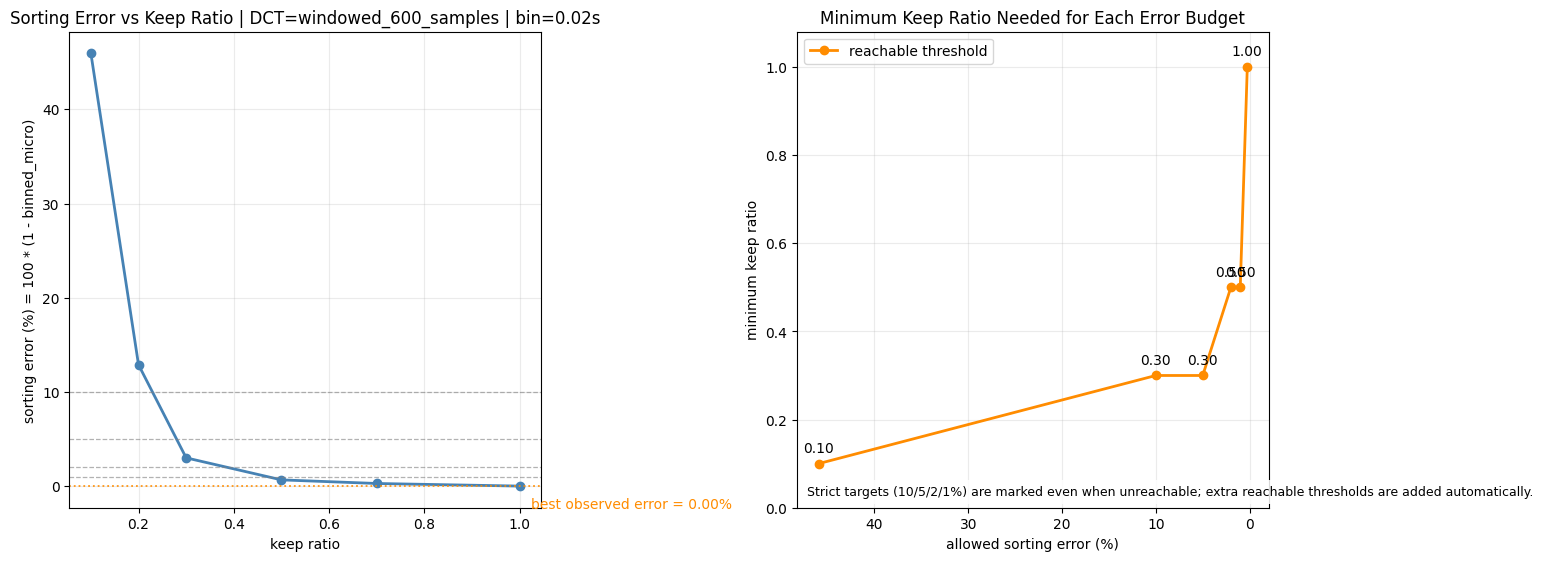

#### Cached config: DCT=windowed_600_samples, bin=0.02s

Week 4 ratio=1.00-baseline table: G:\academic\week4_fixed_template_ratio_compare_dctwin_600samp_600samp_ratio1baseline.csv


,ratio,baseline_reference,binned_count_accuracy_micro_vs_ratio100,binned_count_accuracy_macro_vs_ratio100,matched_spikes_after_binning_vs_ratio100,baseline_spikes_for_binning_vs_ratio100,bin_size_seconds,compressed_bin,int16_meta,sample_rate,source_compare_df
0,0.1,ratio_1.00_fixed_template_rerun,0.540524,0.556159,76603,141720,0.02,G:\academic\whitened_recon_ratio_0.10_dctwin_6...,G:\academic\whitened_recon_ratio_0.10_dctwin_6...,30000.0,custom_compare_df
1,0.2,ratio_1.00_fixed_template_rerun,0.871190,0.888064,123465,141720,0.02,G:\academic\whitened_recon_ratio_0.20_dctwin_6...,G:\academic\whitened_recon_ratio_0.20_dctwin_6...,30000.0,custom_compare_df
2,0.3,ratio_1.00_fixed_template_rerun,0.970018,0.970042,137471,141720,0.02,G:\academic\whitened_recon_ratio_0.30_dctwin_6...,G:\academic\whitened_recon_ratio_0.30_dctwin_6...,30000.0,custom_compare_df
3,0.5,ratio_1.00_fixed_template_rerun,0.993417,0.993463,140787,141720,0.02,G:\academic\whitened_recon_ratio_0.50_dctwin_6...,G:\academic\whitened_recon_ratio_0.50_dctwin_6...,30000.0,custom_compare_df
4,0.7,ratio_1.00_fixed_template_rerun,0.997241,0.997355,141329,141720,0.02,G:\academic\whitened_recon_ratio_0.70_dctwin_6...,G:\academic\whitened_recon_ratio_0.70_dctwin_6...,30000.0,custom_compare_df
5,1.0,ratio_1.00_fixed_template_rerun,1.000000,1.000000,141720,141720,0.02,G:\academic\whitened_recon_ratio_1.00_dctwin_6...,G:\academic\whitened_recon_ratio_1.00_dctwin_6...,30000.0,custom_compare_df


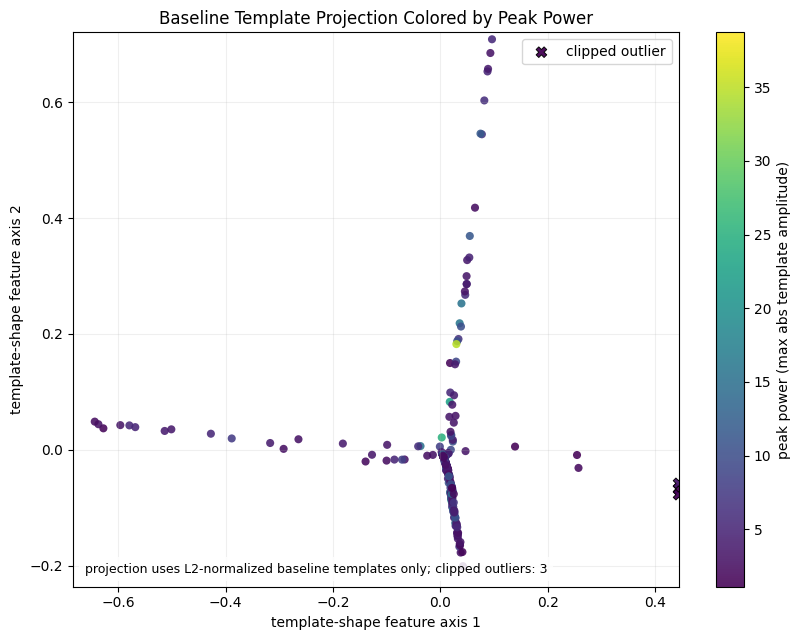

No matching Week 5 neuron-level cache found; skipping sensitive/robust neuron figure.


,allowed_sorting_error_pct,min_keep_ratio,is_requested_threshold,reachable
0,45.95,0.1,False,True
1,10.00,0.3,True,True
2,5.00,0.3,True,True
3,2.00,0.5,True,True
4,1.00,0.5,True,True
5,0.25,1.0,False,True


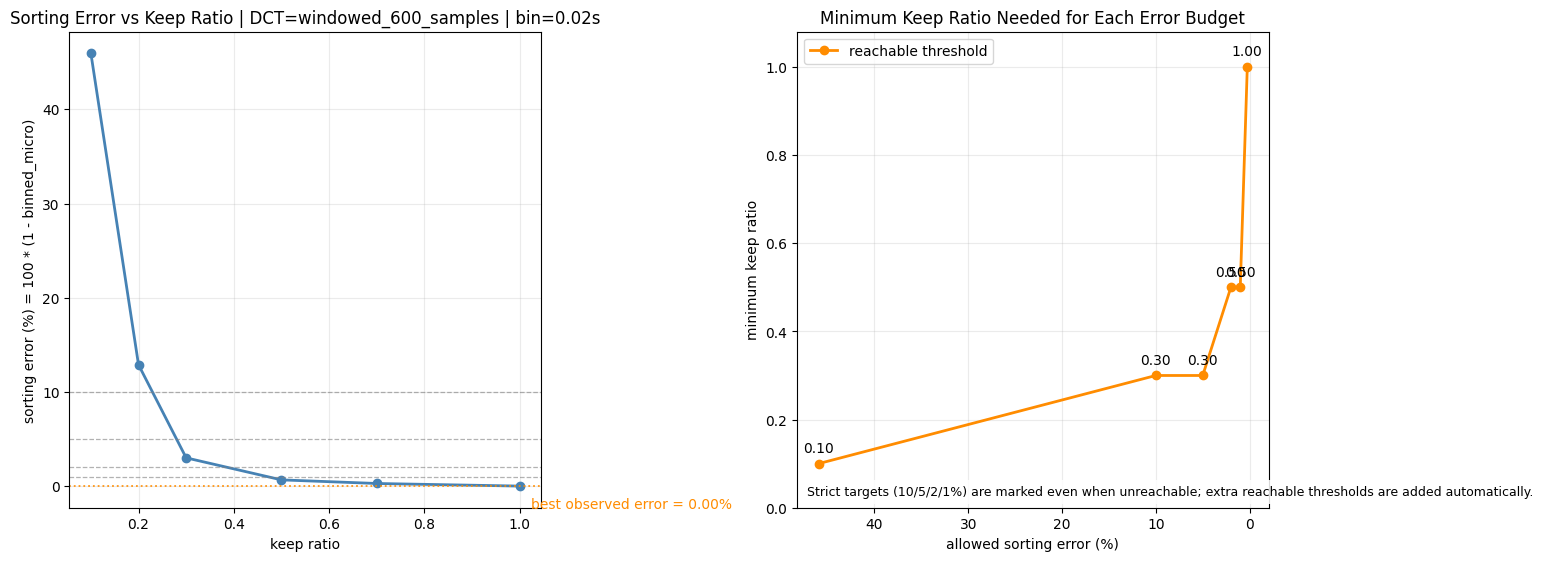

#### Batch render summary

,dct_window_samples,dct_mode,bin_size_samples,bin_size_seconds,ratio_table,week5_neuron_ratio,rendered_neuron_plot,n_week4_eval_caches
0,NaN,full_timeline,15000,0.50,G:\academic\week4_fixed_template_ratio_compare...,NaN,False,6
1,NaN,full_timeline,30000,1.00,G:\academic\week4_fixed_template_ratio_compare...,0.3,True,6
2,600.0,windowed_600_samples,600,0.02,G:\academic\week4_fixed_template_ratio_compare...,NaN,False,6
3,600.0,windowed_600_samples,600,0.02,G:\academic\week4_fixed_template_ratio_compare...,NaN,False,6


,dct_window_samples,dct_mode,bin_size_samples,bin_size_seconds,ratio_table,week5_neuron_ratio,rendered_neuron_plot,n_week4_eval_caches
0,NaN,full_timeline,15000,0.50,G:\academic\week4_fixed_template_ratio_compare...,NaN,False,6
1,NaN,full_timeline,30000,1.00,G:\academic\week4_fixed_template_ratio_compare...,0.3,True,6
2,600.0,windowed_600_samples,600,0.02,G:\academic\week4_fixed_template_ratio_compare...,NaN,False,6
3,600.0,windowed_600_samples,600,0.02,G:\academic\week4_fixed_template_ratio_compare...,NaN,False,6


In [17]:
def _as_optional_int(value):
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return int(value)


def _load_week4_ratio_caches_for_config(ratios, bin_size_samples, sample_rate, window_samples):
    caches = {}
    for ratio in sorted(float(r) for r in ratios):
        cache_path = resolve_week4_ratio_eval_cache_path(
            ratio,
            bin_size_samples,
            sample_rate,
            window_samples=window_samples,
        )
        if not cache_path.exists() or cache_path.stat().st_size == 0:
            continue
        try:
            cached = np.load(cache_path, allow_pickle=True).item()
        except Exception as exc:
            print(f'skip unreadable Week 4 cache {cache_path.name}: {exc}')
            continue
        if isinstance(cached, dict):
            caches[ratio] = cached
    return caches


def _load_cached_neuron_df_for_config(ratios, bin_size_samples, sample_rate, window_samples, preferred_ratio=0.30):
    ordered_ratios = []
    if preferred_ratio is not None:
        ordered_ratios.append(float(preferred_ratio))
    for ratio in ratios:
        ratio = float(ratio)
        if ratio not in ordered_ratios:
            ordered_ratios.append(ratio)

    for ratio in ordered_ratios:
        cached, cache_path = load_week5_neuron_cache(
            ratio,
            bin_size_samples,
            sample_rate,
            pipeline_version=globals().get('WEEK5_PIPELINE_VERSION'),
            window_samples=window_samples,
        )
        if cached is None:
            continue
        neuron_table = cached.get('per_neuron_table')
        neuron_df = pd.DataFrame(neuron_table)
        if neuron_df.empty:
            continue
        print(f'loaded cached Week 5 neuron table for ratio={ratio:.2f}: {cache_path.name}')
        return ratio, neuron_df

    return None, None


def render_all_cached_config_visuals(configs=None, preferred_ratio=0.30, render_template_projection=True):
    configs = discover_week4_cached_configs() if configs is None else configs.copy()
    if configs.empty:
        print('No cached Week 4 configurations found.')
        return pd.DataFrame()

    required_globals = ['templates_base', 'ops_base', 'nt']
    missing = [name for name in required_globals if name not in globals()]
    if missing:
        raise RuntimeError(f'Run the data-import and template-matching setup cells first; missing: {missing}')

    original_state = {
        'DCT_WINDOW_SECONDS': globals().get('DCT_WINDOW_SECONDS', None),
        'DCT_WINDOW_SAMPLES': globals().get('DCT_WINDOW_SAMPLES', None),
        'WEEK5_BIN_SIZE_SECONDS': globals().get('WEEK5_BIN_SIZE_SECONDS', None),
    }

    sample_rate = float(ops_base['fs'])
    render_rows = []

    try:
        for _, cfg in configs.iterrows():
            window_samples = _as_optional_int(cfg.get('dct_window_samples'))
            bin_size_samples = _as_optional_int(cfg.get('bin_size_samples'))
            bin_size_seconds = cfg.get('bin_size_seconds')
            if bin_size_samples is None and pd.notna(bin_size_seconds):
                bin_size_samples = max(1, int(round(float(bin_size_seconds) * sample_rate)))
            if bin_size_samples is None:
                print('skip config with unknown bin size:', cfg.to_dict())
                continue

            globals()['DCT_WINDOW_SAMPLES'] = window_samples
            globals()['DCT_WINDOW_SECONDS'] = None if window_samples is None else window_samples / sample_rate
            globals()['WEEK5_BIN_SIZE_SECONDS'] = bin_size_samples / sample_rate

            display(Markdown(f"#### Cached config: DCT={dct_window_label(window_samples)}, bin={bin_size_samples / sample_rate:g}s"))

            ratio_table_path = resolve_ratio100_baseline_table_path(
                bin_size_samples,
                sample_rate,
                window_samples=window_samples,
            )
            if ratio_table_path.exists():
                ratio_df = pd.read_csv(ratio_table_path)
                print('Week 4 ratio=1.00-baseline table:', ratio_table_path)
            elif Path(cfg.get('ratio_table_csv', '')).exists():
                ratio_table_path = Path(cfg['ratio_table_csv'])
                ratio_df = pd.read_csv(ratio_table_path)
                print('Week 4 ratio table:', ratio_table_path)
            else:
                ratio_df = None
                print('No Week 4 ratio table found for this config.')

            if ratio_df is not None:
                display(ratio_df)
                ratios = ratio_df['ratio'].astype(float).tolist() if 'ratio' in ratio_df.columns else []
            else:
                ratios = cfg.get('available_ratios', []) or []

            if render_template_projection:
                render_template_projection_for_current_config(templates_base)

            neuron_ratio, cached_neuron_df = _load_cached_neuron_df_for_config(
                ratios,
                bin_size_samples,
                sample_rate,
                window_samples,
                preferred_ratio=preferred_ratio,
            )
            rendered_neuron_plot = cached_neuron_df is not None
            if rendered_neuron_plot:
                render_sensitive_robust_for_current_config(templates_base, cached_neuron_df, ops_base, nt)
            else:
                print('No matching Week 5 neuron-level cache found; skipping sensitive/robust neuron figure.')

            week4_caches = _load_week4_ratio_caches_for_config(ratios, bin_size_samples, sample_rate, window_samples)
            render_error_budget_for_current_config(ratio_df, week4_caches)

            render_rows.append({
                'dct_window_samples': window_samples,
                'dct_mode': dct_window_label(window_samples),
                'bin_size_samples': bin_size_samples,
                'bin_size_seconds': bin_size_samples / sample_rate,
                'ratio_table': str(ratio_table_path) if ratio_df is not None else None,
                'week5_neuron_ratio': neuron_ratio,
                'rendered_neuron_plot': rendered_neuron_plot,
                'n_week4_eval_caches': len(week4_caches),
            })
    finally:
        for name, value in original_state.items():
            globals()[name] = value

    summary_df = pd.DataFrame(render_rows)
    if not summary_df.empty:
        display(Markdown('#### Batch render summary'))
        display(summary_df)
    return summary_df


render_all_cached_config_visuals()


### Optional Backfill

Run the next cell only if you want to generate or migrate missing `week5_neuron_sensitivity_ratio_*` caches. This is not required for pure cache-backed visualization.


In [18]:
# Optional: generate/migrate missing Week 5 neuron-level caches from existing Week 4 outputs.
# backfill_all_week5_neuron_caches()


In [19]:
export_path = week5_neuron_csv_path(analysis_ratio, week5_bin_size_samples, float(ops_base['fs']))
neuron_df.to_csv(export_path, index=False)
print('saved:', export_path)


saved: G:\academic\week5_neuron_sensitivity_ratio_0.30_full_30000sampbin_ratio1baseline.csv


## 3. Accuracy Predictor for Probe Data and Compression Ratio

This section builds a reusable predictor that estimates `binned_count_accuracy` from probe-level neuron features and a chosen compression ratio.

Selected features used by the model:

- `compression_ratio`: the input compression ratio
- `baseline_spikes`: baseline spike count of the neuron
- `firing_rate_hz`: baseline firing rate over the recording
- `template_ptp_mean`: mean peak-to-peak amplitude across channels
- `template_ptp_max`: max peak-to-peak amplitude across channels
- `template_energy`: mean squared template energy
- `dominant_channel`: channel index with the largest template peak-to-peak amplitude
- `template_width_samples`: distance between template trough and peak on the dominant channel

The target is per-neuron `binned_count_accuracy`. Probe-level predicted accuracy is the mean of predicted neuron accuracies for that probe.


In [20]:
predictor_cache = predictor_training_cache_path(week5_bin_size_samples, float(ops_base['fs']))
predictor_model_path = predictor_model_cache_path(week5_bin_size_samples, float(ops_base['fs']))
predictor_cache.parent.mkdir(parents=True, exist_ok=True)
predictor_feature_df = extract_baseline_neuron_features(templates_base, st_ref, clu_ref, sample_rate=float(ops_base['fs']))
predictor_feature_df.head()


,neuron_id,baseline_spikes,firing_rate_hz,template_ptp_mean,template_ptp_max,template_energy,dominant_channel,template_width_samples
0,0,840,18.667510,0.030026,4.468421,0.004847,3,23
1,1,631,14.022856,0.034374,3.342264,0.004241,3,13
2,2,1195,26.556756,0.036586,4.025699,0.004520,2,15
3,3,1413,31.401419,0.022977,4.626841,0.004303,1,20
4,4,1588,35.290483,0.023190,4.502786,0.004064,1,17


In [21]:
# RERUN NOTE: Must rerun after reconstructed bins and week5_neuron_sensitivity_ratio_*.npy are refreshed. This cell assembles the predictor training set using the ratio=1.00 fixed-template rerun as the baseline reference.
training_ratios = [0.10, 0.20, 0.30, 0.50, 0.70]
predictor_records = []

for ratio in training_ratios:
    ratio_neuron_df = load_or_build_week5_neuron_table(
        ratio,
        st_ref,
        clu_ref,
        U=U,
        ctc=ctc,
        ops_tm=ops_tm,
        n_use=n_use,
        nt=nt,
        device=device,
        bin_size_samples=week5_bin_size_samples,
        sample_rate=float(ops_base['fs']),
        window_samples=DCT_WINDOW_SAMPLES,
    )
    if ratio_neuron_df is None:
        continue
    predictor_records.append(build_ratio_feature_frame(predictor_feature_df, ratio, ratio_neuron_df))

predictor_train_df = pd.concat(predictor_records, ignore_index=True)
predictor_train_df = predictor_train_df[predictor_train_df['baseline_spikes'] > 0].copy()
predictor_train_df.to_csv(predictor_cache, index=False)
print('saved training data:', predictor_cache)
print('training rows:', len(predictor_train_df))
display(predictor_train_df.head())


loaded cached neuron table for ratio=0.10: week5_neuron_sensitivity_ratio_0.10_full_30000sampbin_ratio1baseline.npy
loaded cached neuron table for ratio=0.20: week5_neuron_sensitivity_ratio_0.20_full_30000sampbin_ratio1baseline.npy
loaded cached neuron table for ratio=0.30: week5_neuron_sensitivity_ratio_0.30_full_30000sampbin_ratio1baseline.npy
loaded cached neuron table for ratio=0.50: week5_neuron_sensitivity_ratio_0.50_full_30000sampbin_ratio1baseline.npy
loaded cached neuron table for ratio=0.70: week5_neuron_sensitivity_ratio_0.70_full_30000sampbin_ratio1baseline.npy
saved training data: G:\academic\predictor\week5_accuracy_predictor_training_data_ratio1baseline.csv
training rows: 1335


,neuron_id,baseline_spikes,firing_rate_hz,template_ptp_mean,template_ptp_max,template_energy,dominant_channel,template_width_samples,compression_ratio,compression_ratio_sq,binned_count_accuracy,sensitivity,compressed_spikes
0,0,840,18.667510,0.030026,4.468421,0.004847,3,23,0.1,0.01,0.661905,0.338095,556
1,1,631,14.022856,0.034374,3.342264,0.004241,3,13,0.1,0.01,0.549921,0.450079,347
2,2,1195,26.556756,0.036586,4.025699,0.004520,2,15,0.1,0.01,0.390795,0.609205,467
3,3,1413,31.401419,0.022977,4.626841,0.004303,1,20,0.1,0.01,0.864827,0.135173,1258
4,4,1588,35.290483,0.023190,4.502786,0.004064,1,17,0.1,0.01,0.910579,0.089421,1480


In [22]:
# RERUN NOTE: Rerun after the predictor training-set cell above. This retrains and overwrites the saved predictor model using post-CAR targets.
feature_columns = list(DEFAULT_FEATURE_COLUMNS)
target_column = 'binned_count_accuracy'

predictor_model = AccuracyPredictorModel.train(
    predictor_train_df,
    feature_columns=feature_columns,
    target_column=target_column,
    alpha=1.0,
)
predictor_model.save(predictor_model_path)

train_pred_df = predictor_model.predict_dataframe(predictor_train_df)
cv_df, cv_summary = leave_one_ratio_out_cv(
    predictor_train_df,
    feature_columns=feature_columns,
    target_column=target_column,
    alpha=1.0,
)

coef_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': predictor_model.coefficients_
}).sort_values('coefficient', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print('saved model:', predictor_model_path)
print('training metrics:', predictor_model.training_metrics_)
print('leave-one-ratio-out summary:', cv_summary)
display(cv_df)
display(coef_df)


saved model: G:\academic\predictor\week5_accuracy_predictor_model_ratio1baseline.npy
training metrics: {'mae': 0.09086093997446708, 'rmse': 0.1376991620665871, 'r2': 0.5399683602597765}
leave-one-ratio-out summary: {'mae': 0.16054093240345213, 'rmse': 0.23554071877879207, 'r2': -0.34603731433479057}


,held_out_ratio,mae,rmse,r2
0,0.1,0.250583,0.348091,-0.599681
1,0.2,0.133904,0.153497,-0.258919
2,0.3,0.053906,0.071881,-2.382630
3,0.5,0.013365,0.022531,-3.760546
4,0.7,0.350945,0.356362,-4509.448453


,feature,coefficient
0,compression_ratio,0.497420
1,compression_ratio_sq,-0.391803
2,template_ptp_max,-0.034709
3,template_width_samples,0.033255
4,template_ptp_mean,0.014893
5,template_energy,-0.012149
6,baseline_spikes,-0.001736
7,firing_rate_hz,-0.001736
8,dominant_channel,0.001468


In [23]:
example_ratio = 0.30
probe_prediction = predictor_model.predict_probe_accuracy_from_files(
    templates_path=BASE_RESULTS / 'templates.npy',
    spike_times_path=BASE_RESULTS / 'spike_times.npy',
    spike_clusters_path=BASE_RESULTS / 'spike_clusters.npy',
    ops_path=BASE_RESULTS / 'ops.npy',
    ratio=example_ratio,
)
print('example ratio:', example_ratio)
print('predicted probe mean accuracy:', probe_prediction['predicted_probe_accuracy_mean'])
display(
    probe_prediction['predicted_neuron_accuracy_table'][['neuron_id', 'compression_ratio', 'predicted_accuracy']].head(10)
)


example ratio: 0.3
predicted probe mean accuracy: 0.935309981988113


,neuron_id,compression_ratio,predicted_accuracy
0,0,0.3,0.994249
1,1,0.3,0.940885
2,2,0.3,0.945768
3,3,0.3,0.967538
4,4,0.3,0.948746
5,5,0.3,0.885376
6,6,0.3,0.871154
7,7,0.3,0.978983
8,8,0.3,0.970610
9,9,0.3,0.993134


### How to Call the Predictor from Python

The reusable implementation is stored in `predictor/accuracy_predictor.py`.

Shortest file-based call:

```python
from pathlib import Path
from predictor.accuracy_predictor import AccuracyPredictorModel

ROOT = Path('G:/academic')
BASE_RESULTS = ROOT / '.test_data/kilosort4'

model = AccuracyPredictorModel.load(ROOT / 'predictor/week5_accuracy_predictor_model.npy')
result = model.predict_probe_accuracy_from_files(
    templates_path=BASE_RESULTS / 'templates.npy',
    spike_times_path=BASE_RESULTS / 'spike_times.npy',
    spike_clusters_path=BASE_RESULTS / 'spike_clusters.npy',
    ops_path=BASE_RESULTS / 'ops.npy',
    ratio=0.30,
)

print(result['predicted_probe_accuracy_mean'])
print(result['predicted_neuron_accuracy_table'].head())
```

If you already have arrays in memory, you can still use `extract_baseline_neuron_features(...)` plus `predict_probe_accuracy(...)`.


### How to Call the Best Compression Ratio Recommender

The new reusable implementation is stored in `ratio_recommender/best_ratio_recommender.py`.

Rule used by this recommender:

- Treat compression ratio as a continuous variable over a configured interval.
- Predict `predicted_probe_accuracy_mean` for each candidate `keep_ratio`.
- Impose a hard constraint `predicted_probe_accuracy_mean >= min_accuracy_threshold`.
- Among all feasible ratios, choose the minimum `keep_ratio`.
- If no ratio reaches the threshold, fall back to the ratio with the highest predicted probe accuracy in the search interval.
- When multiple probe inputs are given, the output is a vector-like table with one recommended `keep_ratio` per probe.

Shortest file-based call:

```python
from pathlib import Path
from ratio_recommender import CompressionRatioRecommender

ROOT = Path('G:/academic')
BASE_RESULTS = ROOT / '.test_data/kilosort4'

recommender = CompressionRatioRecommender.load(
    ROOT / 'predictor/week5_accuracy_predictor_model.npy',
    min_ratio=0.10,
    max_ratio=0.90,
    min_accuracy_threshold=0.80,
    search_tolerance=1e-4,
)

result = recommender.recommend_probe_ratio_from_files(
    templates_path=BASE_RESULTS / 'templates.npy',
    spike_times_path=BASE_RESULTS / 'spike_times.npy',
    spike_clusters_path=BASE_RESULTS / 'spike_clusters.npy',
    ops_path=BASE_RESULTS / 'ops.npy',
    probe_name='example_probe',
)

print(result['recommended_keep_ratio'])
print(result['recommended_predicted_probe_accuracy_mean'])
print(result['ratio_evaluation_table'])
```


In [24]:
from ratio_recommender import CompressionRatioRecommender

recommender = CompressionRatioRecommender.load(
    ROOT / 'predictor/week5_accuracy_predictor_model.npy',
    min_ratio=0.10,
    max_ratio=1.00,
    min_accuracy_threshold=0.60,
    search_tolerance=1e-4,
)

single_probe_best_ratio = recommender.recommend_probe_ratio_from_files(
    templates_path=BASE_RESULTS / 'templates.npy',
    spike_times_path=BASE_RESULTS / 'spike_times.npy',
    spike_clusters_path=BASE_RESULTS / 'spike_clusters.npy',
    ops_path=BASE_RESULTS / 'ops.npy',
    probe_name='baseline_probe',
)

print('recommended keep_ratio:', single_probe_best_ratio['recommended_keep_ratio'])
print('predicted probe mean accuracy at recommended keep_ratio:', single_probe_best_ratio['recommended_predicted_probe_accuracy_mean'])
print('threshold feasible:', single_probe_best_ratio['threshold_feasible'])
print('selection rule:', single_probe_best_ratio['selection_rule'])
display(single_probe_best_ratio['ratio_evaluation_table'])


recommended keep_ratio: 0.12812500000000002
predicted probe mean accuracy at recommended keep_ratio: 0.619397574797741
threshold feasible: True
selection rule: minimum_keep_ratio_meeting_threshold


,compression_ratio,predicted_probe_accuracy_mean,meets_min_accuracy_threshold
0,0.100000,0.592449,False
1,0.128125,0.619398,True
2,0.156250,0.644276,True
3,0.184375,0.667137,True
4,0.212500,0.688013,True
5,0.240625,0.706903,True
6,0.268750,0.723808,True
7,0.296875,0.738727,True
8,0.325000,0.751641,True
9,0.353125,0.762548,True


In [25]:
from ratio_recommender import CompressionRatioRecommender

recommender = CompressionRatioRecommender.load(
    ROOT / 'predictor/week5_accuracy_predictor_model.npy',
    min_ratio=0.10,
    max_ratio=1.00,
    min_accuracy_threshold=0.60,
    search_tolerance=1e-4,
)

probe_specs = [
    {
        'probe_name': 'baseline_probe_a',
        'templates_path': BASE_RESULTS / 'templates.npy',
        'spike_times_path': BASE_RESULTS / 'spike_times.npy',
        'spike_clusters_path': BASE_RESULTS / 'spike_clusters.npy',
        'ops_path': BASE_RESULTS / 'ops.npy',
    },
    {
        'probe_name': 'baseline_probe_b',
        'templates_path': BASE_RESULTS / 'templates.npy',
        'spike_times_path': BASE_RESULTS / 'spike_times.npy',
        'spike_clusters_path': BASE_RESULTS / 'spike_clusters.npy',
        'ops_path': BASE_RESULTS / 'ops.npy',
    },
]

batch_result = recommender.recommend_many_from_files(probe_specs)
display(batch_result['keep_ratio_vector_table'])


,probe_name,recommended_keep_ratio,recommended_predicted_probe_accuracy_mean,selection_rule,threshold_feasible,min_accuracy_threshold
0,baseline_probe_a,0.128125,0.619398,minimum_keep_ratio_meeting_threshold,True,0.6
1,baseline_probe_b,0.128125,0.619398,minimum_keep_ratio_meeting_threshold,True,0.6
